In [97]:
import os

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

import re

import warnings

warnings.filterwarnings('ignore')

### Наш дашборд

https://datalens.yandex/mw1f2npokces8

P.S. Обращайте внимания на вкладки, как по страницам, так и по графикам

# Преданализ

In [98]:
data = pd.read_csv('ecom_yl.csv')
data.columns = data.columns.str.lower().str.replace(' ', '_')
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.000000,2019-05-01,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,2019-05-01,5,3,7,NaN,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,2019-05-01,5,3,4,NaN,NaN,NaN,NaN
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,2019-05-01,5,3,18,NaN,NaN,NaN,NaN
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,2019-05-02,5,4,14,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,2019-10-29,10,2,18,NaN,NaN,NaN,NaN
1008,660140862425,germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,2019-10-30,10,3,19,NaN,NaN,NaN,NaN
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,2019-10-30,10,3,4,NaN,NaN,NaN,NaN
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,2019-10-31,10,4,23,NaN,NaN,NaN,NaN


### Анализируем Nan

Text(0, 0.5, 'Название столбца')

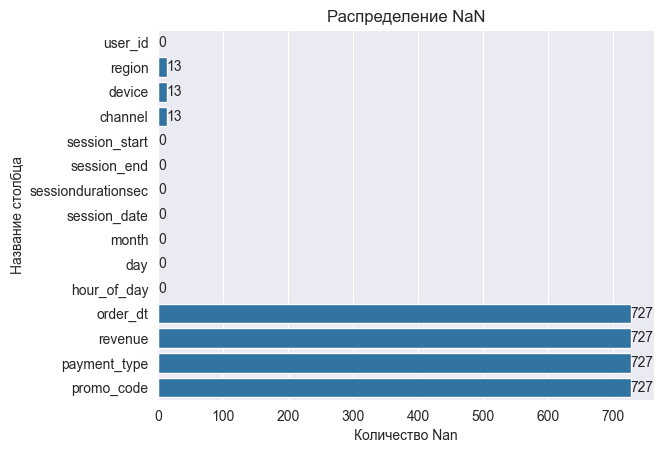

In [99]:
ax = sns.barplot(y=data.isna().sum().index, x=data.isna().sum().values)
for i in ax.containers:
    ax.bar_label(i)
plt.title('Распределение NaN')
plt.xlabel('Количество Nan')
plt.ylabel('Название столбца')

In [100]:
data[data['device'].isna()]

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
303,434852403169,NaN,NaN,NaN,2019-07-01 07:36:39,2019-07-01 07:52:15,936.0,2019-07-01,7,1,7,2019-07-01 07:36:46,4999.0,Debit card,1.0
392,213468351687,NaN,NaN,NaN,2019-07-20 21:19:14,2019-07-20 21:32:09,775.0,2019-07-20,7,6,21,NaN,NaN,NaN,NaN
429,679176482300,NaN,NaN,NaN,2019-07-28 02:19:45,2019-07-28 03:04:59,2714.0,2019-07-28,7,7,3,NaN,NaN,NaN,NaN
547,87458247642,NaN,NaN,NaN,2019-08-16 17:33:09,2019-08-16 18:02:53,1784.0,2019-08-16,8,5,18,2019-08-16 17:33:25,4999.0,Credit card,0.0
549,588840798518,NaN,NaN,NaN,2019-08-16 16:46:22,2019-08-16 17:34:45,2903.0,2019-08-16,8,5,17,2019-08-16 16:47:07,4999.0,E-wallet,0.0
564,61219447121,NaN,NaN,NaN,2019-08-18 08:16:27,2019-08-18 08:28:59,752.0,2019-08-18,8,7,8,2019-08-18 08:16:33,4999.0,Cash,0.0
599,16254498222,NaN,NaN,NaN,2019-08-25 13:21:44,2019-08-25 13:43:23,1299.0,2019-08-25,8,7,13,2019-08-25 13:21:55,4999.0,Cash,1.0
600,16254498222,NaN,NaN,NaN,2019-08-25 13:21:44,2019-08-25 13:43:23,1299.0,2019-08-25,8,7,13,2019-08-25 13:21:55,4999.0,Cash,1.0
652,427486793654,NaN,NaN,NaN,2019-09-03 06:02:54,2019-09-03 07:00:02,3428.0,2019-09-03,9,2,7,2019-09-03 06:03:39,4999.0,Debit card,1.0
686,632186207840,NaN,NaN,NaN,2019-09-10 07:21:58,2019-09-10 07:45:43,1425.0,2019-09-10,9,2,7,NaN,NaN,NaN,NaN


У 13 строчек (~1% датасета) отсутствуют ключевые для нас показатели: регион и канал. 

Поэтому мы их удаляем.

In [101]:
data = data[data['region'].isna() == False][data['device'].isna() == False][data['channel'].isna() == False]
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.000000,2019-05-01,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,2019-05-01,5,3,7,NaN,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,2019-05-01,5,3,4,NaN,NaN,NaN,NaN
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,2019-05-01,5,3,18,NaN,NaN,NaN,NaN
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,2019-05-02,5,4,14,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,2019-10-29,10,2,18,NaN,NaN,NaN,NaN
1008,660140862425,germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,2019-10-30,10,3,19,NaN,NaN,NaN,NaN
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,2019-10-30,10,3,4,NaN,NaN,NaN,NaN
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,2019-10-31,10,4,23,NaN,NaN,NaN,NaN


Пропуски в строках order_dt, revenue и тп. означают, что человек зашёл на сайт, но не оформил заказ

In [102]:
data.promo_code.unique()

array([0.        ,        nan, 1.        , 0.86271506])

Также, есть тех ошибки в столбце с промокодами (некоторые бинарные значения равны - 0.86271506), удаляем 3 строки (~0.3% датасета)

In [103]:
data['promo_code'] = data['promo_code'].fillna(0)
data = data[data['promo_code'].isin([0, 1])]
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.000000,2019-05-01,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,2019-05-01,5,3,7,NaN,NaN,NaN,0.0
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,2019-05-01,5,3,4,NaN,NaN,NaN,0.0
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,2019-05-01,5,3,18,NaN,NaN,NaN,0.0
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,2019-05-02,5,4,14,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,2019-10-29,10,2,18,NaN,NaN,NaN,0.0
1008,660140862425,germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,2019-10-30,10,3,19,NaN,NaN,NaN,0.0
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,2019-10-30,10,3,4,NaN,NaN,NaN,0.0
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,2019-10-31,10,4,23,NaN,NaN,NaN,0.0


### Анализируем дубликаты

In [104]:
data.region.unique()

array(['United States', 'Frаnce', 'Unjted States', 'Germany', 'UK',
       'France', 'Frаncе', 'Franсe', 'germany', 'UК'], dtype=object)

In [105]:
data.device.unique()

array(['iPhone', 'PC', 'Mac', 'Android', 'android'], dtype=object)

In [106]:
data.channel.unique()

array(['социальные сети', 'organic', 'реклама у блогеров',
       'контексная реклама', 'email-рассылки', 'контекстная реклама'],
      dtype=object)

In [107]:
data.month.unique()

array([ 5,  6,  7,  8,  9, 10])

In [108]:
data.day.unique()

array([3, 4, 5, 6, 7, 1, 2])

In [109]:
data.hour_of_day.unique()

array([ 0,  7,  4, 18, 14,  8, 16, 10, 19, 20, 11,  9, 22, 21,  3, 15,  2,
       13,  5,  1, 23,  6, 12, 17])

In [110]:
data.payment_type.unique()

array(['Mobile payments', nan, 'Debit card', 'E-wallet', 'Cash',
       'Credit card'], dtype=object)

Дубликаты есть, заменяем

In [111]:
data['region'] = data['region'].replace({
    'Frаnce': 'France',
    'Franсe': 'France',
    'Frаncе': 'France',
    'Unjted States': 'arged States',
    'germany': 'Germany',
    'UК': 'UK',
    'uk': 'UK'
})

In [112]:
data['europe'] = (data['region'].isin(['France', 'Germany', 'UK'])).astype(int)
data['phone'] = (data['device'].isin(['Android', 'iPhone'])).astype(int)

In [113]:
data['channel'].unique()

array(['социальные сети', 'organic', 'реклама у блогеров',
       'контексная реклама', 'email-рассылки', 'контекстная реклама'],
      dtype=object)

In [114]:
data['device'] = data['device'].replace({
    'android': 'Android',
})

In [115]:
data['channel'] = data['channel'].replace({
    'контексная реклама': 'контекстная реклама',
})

Проанализируем, есть ли полные строки-дубликаты. Поскольку датасета строка содержит очень точную информацию (даты с точностью до секунд), то дубликатов быть не должно (т.к. человек не может два раза зайти и выйти в одно и то же время). Поэтому строки-дубликаты удалим, так как они, скорее всего, являются просто ошибкой системы.

In [116]:
print(f"Строк-Дубликатов: {data.duplicated().sum()}")

Строк-Дубликатов: 1


Есть одна строка-дубликат! Удаляем.

In [117]:
data.drop_duplicates(inplace=True)

### Делаем таблицу удобной

##### Переводим в формат datetime

In [118]:
del data['session_date'] #бесполезный столбец, данные можно взять из session_start, session_end, order_dt

data['session_start'] = pd.to_datetime(data['session_start'])
data['session_end'] = pd.to_datetime(data['session_end'])
data['order_dt'] = pd.to_datetime(data['order_dt'])
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,europe,phone
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.000000,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0,0,1
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,5,3,7,NaT,NaN,NaN,0.0,0,0
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,5,3,4,NaT,NaN,NaN,0.0,0,0
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,5,3,18,NaT,NaN,NaN,0.0,0,1
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,5,4,14,NaT,NaN,NaN,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,10,2,18,NaT,NaN,NaN,0.0,0,1
1008,660140862425,Germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,10,3,19,NaT,NaN,NaN,0.0,1,1
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,10,3,4,NaT,NaN,NaN,0.0,1,1
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,10,4,23,NaT,NaN,NaN,0.0,0,1


##### Флаг покупки (платящий или нет)

In [119]:
data['payer'] = data['revenue'].isna().apply(lambda x: 0 if x else 1) #покупка - 1; нет - 0

##### Итоговая цена (с учётом скидки)

In [120]:
data['final_price'] = data.apply(lambda row: row['revenue'] * 0.9 if row['promo_code'] == 1 else row['revenue'], axis=1)

##### Период визита (время суок)

In [121]:
def time_period(h):
    if 6 <= h < 10:
        return 'Утро'
    elif 10 <= h < 17:
        return 'День'
    elif 17 <= h < 22:
        return 'Вечер'
    else:
        return 'Ночь'
    
data['time_period'] = data['session_start'].dt.hour.apply(time_period)

In [122]:
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,europe,phone,payer,final_price,time_period
0,529697267522,United States,iPhone,социальные сети,2019-05-01 00:06:40,2019-05-01 00:07:06,26.000000,5,3,0,2019-05-01 00:06:40,9999.0,Mobile payments,0.0,0,1,1,9999.0,Ночь
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,5,3,7,NaT,NaN,NaN,0.0,0,0,0,NaN,Утро
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,5,3,4,NaT,NaN,NaN,0.0,0,0,0,NaN,Ночь
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,5,3,18,NaT,NaN,NaN,0.0,0,1,0,NaN,Вечер
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,5,4,14,NaT,NaN,NaN,0.0,0,0,0,NaN,День
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,10,2,18,NaT,NaN,NaN,0.0,0,1,0,NaN,Вечер
1008,660140862425,Germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,10,3,19,NaT,NaN,NaN,0.0,1,1,0,NaN,Вечер
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,10,3,4,NaT,NaN,NaN,0.0,1,1,0,NaN,Ночь
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,10,4,23,NaT,NaN,NaN,0.0,0,1,0,NaN,Ночь


### Графический анализ

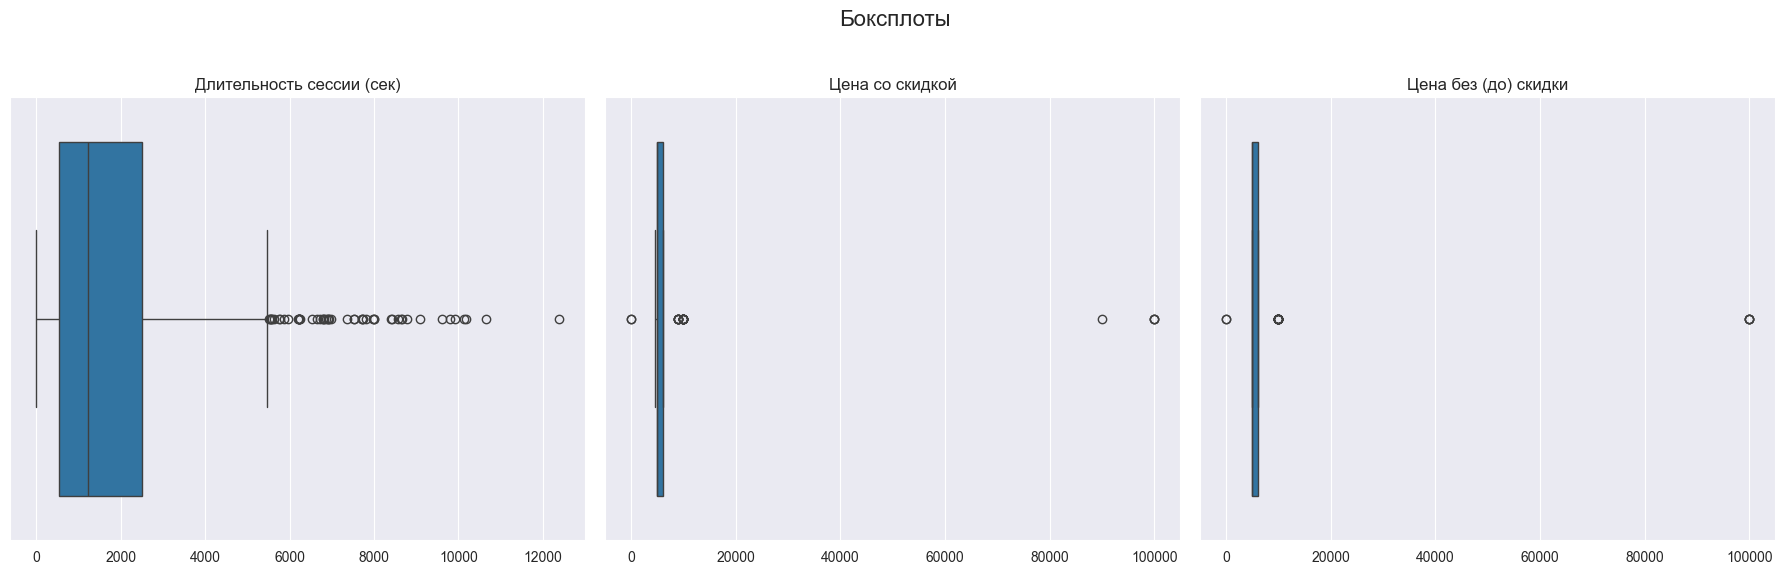

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Боксплоты', fontsize=16)

sns.boxplot(ax=axes[0], data=data, x='sessiondurationsec')
axes[0].set_title('Длительность сессии (сек)')
axes[0].set_xlabel('')

sns.boxplot(ax=axes[1], data=data, x='final_price')
axes[1].set_title('Цена со скидкой')
axes[1].set_xlabel('')

sns.boxplot(ax=axes[2], data=data, x='revenue')
axes[2].set_title('Цена без (до) скидки')
axes[2].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##### Выбросы

По выбросам имеет смысл смотреть только цену товара, потому что в длительности сессии всё адекватно, максимальное значение 12000 с = ~3.3 ч, что звучит реалистично, в то время как в цене товаров есть товары цена которых значительно отличается от цены других товаров из-за чего в один из дней образуется "пик" в 300к прибыли.

In [124]:
def bp_drop(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lw = Q1 - 1.5 * IQR
    up = Q3 + 1.5 * IQR

    new_data = df[((df[column] >= lw) & (df[column] <= up)) | (df[column].isna())].copy()
    return new_data

data = bp_drop(data, 'revenue')

Удалили 23 строчки (~2,27% датасета).

In [125]:
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,europe,phone,payer,final_price,time_period
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,5,3,7,NaT,NaN,NaN,0.0,0,0,0,NaN,Утро
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,5,3,4,NaT,NaN,NaN,0.0,0,0,0,NaN,Ночь
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,5,3,18,NaT,NaN,NaN,0.0,0,1,0,NaN,Вечер
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,5,4,14,NaT,NaN,NaN,0.0,0,0,0,NaN,День
5,271758921583,United States,iPhone,социальные сети,2019-05-02 08:40:35,2019-05-02 08:41:15,40.000000,5,4,8,NaT,NaN,NaN,0.0,0,1,0,NaN,Утро
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,10,2,18,NaT,NaN,NaN,0.0,0,1,0,NaN,Вечер
1008,660140862425,Germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,10,3,19,NaT,NaN,NaN,0.0,1,1,0,NaN,Вечер
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,10,3,4,NaT,NaN,NaN,0.0,1,1,0,NaN,Ночь
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,10,4,23,NaT,NaN,NaN,0.0,0,1,0,NaN,Ночь


##### Графический анализ. Продолжение.

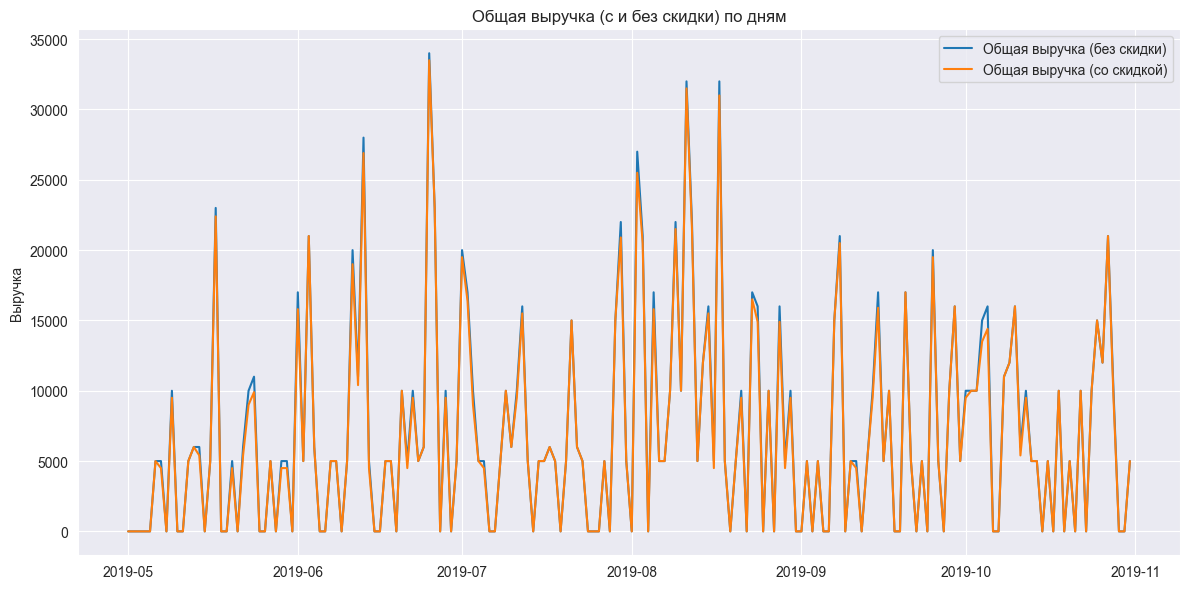

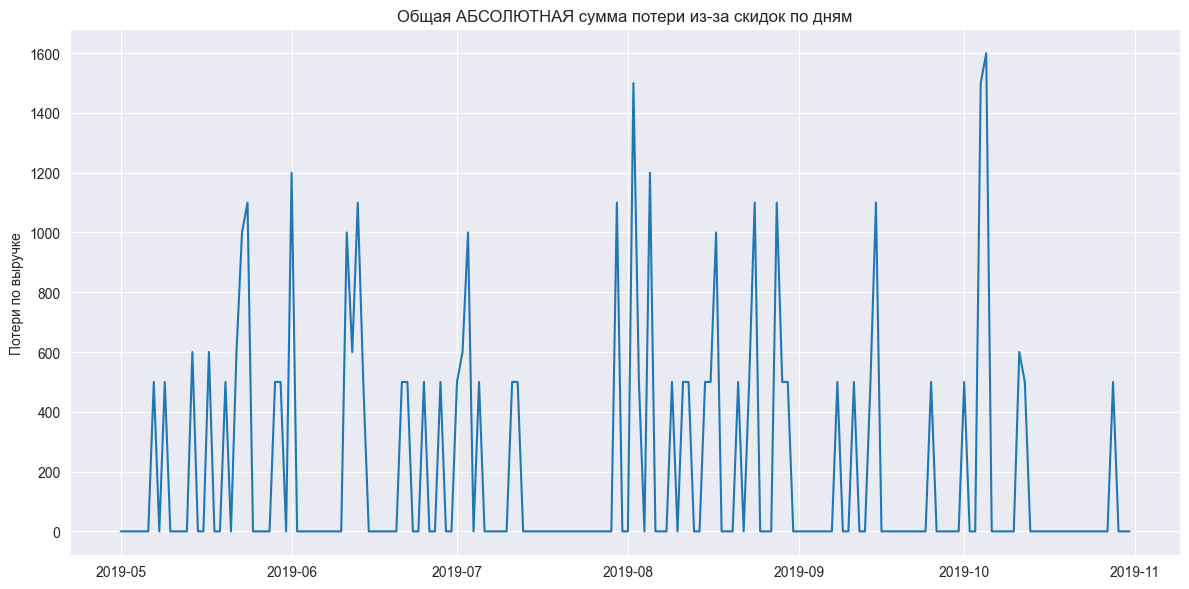

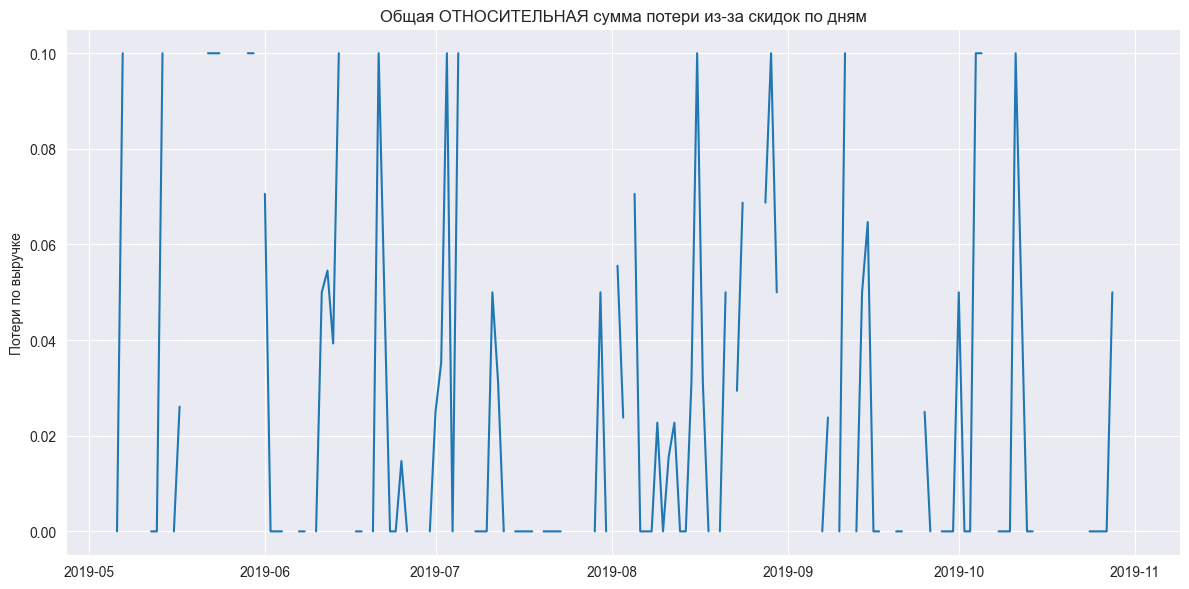

In [126]:
daily_rev_data = data.groupby(pd.Grouper(key='session_start', freq='D')).agg(
    total_revenue=('revenue', 'sum'),
    total_final_price=('final_price', 'sum')
).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_rev_data['session_start'], daily_rev_data['total_revenue'], label='Общая выручка (без скидки)')
plt.plot(daily_rev_data['session_start'], daily_rev_data['total_final_price'], label='Общая выручка (со скидкой)')
plt.ylabel('Выручка')
plt.title('Общая выручка (с и без скидки) по дням')
plt.legend()
plt.tight_layout()
plt.grid(True)

plt.show()

daily_rev_data['delta'] = daily_rev_data['total_revenue'] - daily_rev_data['total_final_price']
plt.figure(figsize=(12, 6))
plt.plot(daily_rev_data['session_start'], daily_rev_data['delta'])
plt.ylabel('Потери по выручке')
plt.title('Общая АБСОЛЮТНАЯ сумма потери из-за скидок по дням')
plt.tight_layout()
plt.grid(True)

plt.show()

daily_rev_data['alfa'] = (daily_rev_data['total_revenue'] - daily_rev_data['total_final_price']) / daily_rev_data['total_revenue']
plt.figure(figsize=(12, 6))
plt.plot(daily_rev_data['session_start'], daily_rev_data['alfa'])
plt.ylabel('Потери по выручке')
plt.title('Общая ОТНОСИТЕЛЬНАЯ сумма потери из-за скидок по дням')
plt.tight_layout()
plt.grid(True)

plt.show()

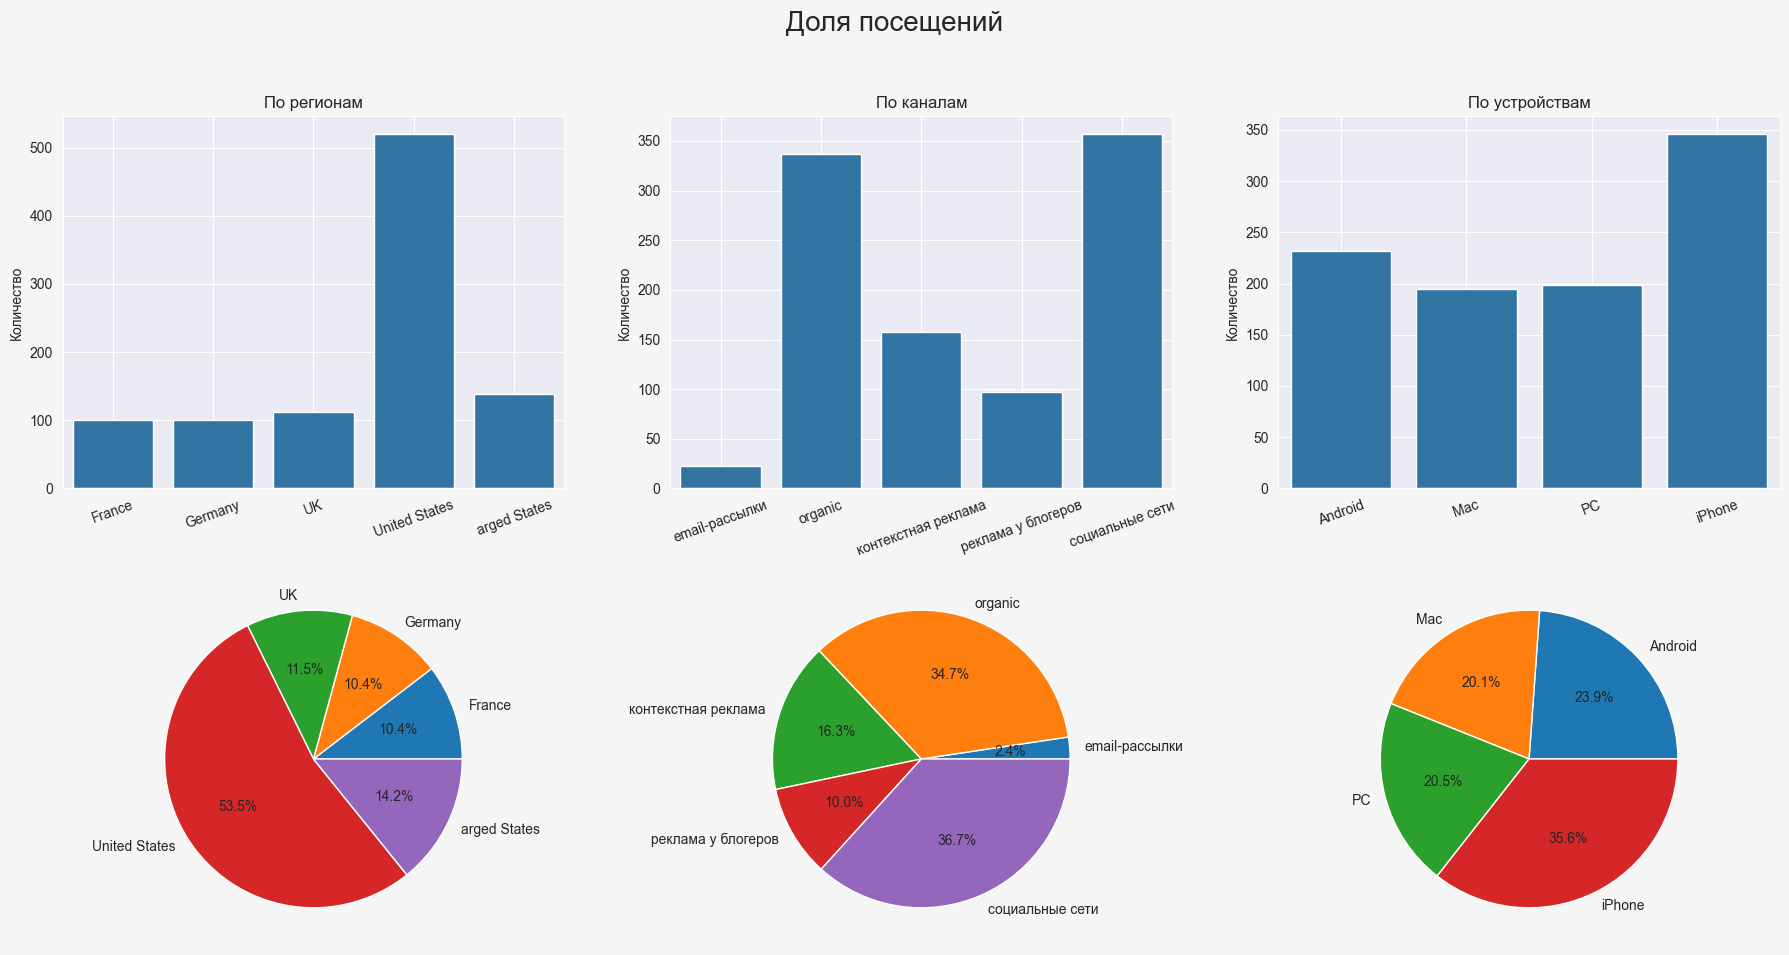

In [127]:
titles = ['По регионам', 'По каналам', 'По устройствам']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Доля посещений', fontsize=20)

for i, col in enumerate(['region', 'channel', 'device']):
    spec_data = pd.DataFrame(data.groupby(col)['user_id'].count()).reset_index()
    sns.barplot(data=spec_data, x=col, y='user_id', ax=axes[0, i])
    axes[0, i].set_title(titles[i])
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Количество')
    axes[0, i].set_axisbelow(True)
    axes[0, i].tick_params(axis='x', rotation=20)

    axes[1, i].pie(spec_data['user_id'], labels=spec_data[col], autopct='%1.1f%%')

for ax in axes.flatten():
    ax.grid(True)

fig.patch.set_facecolor('#F5F5F5')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


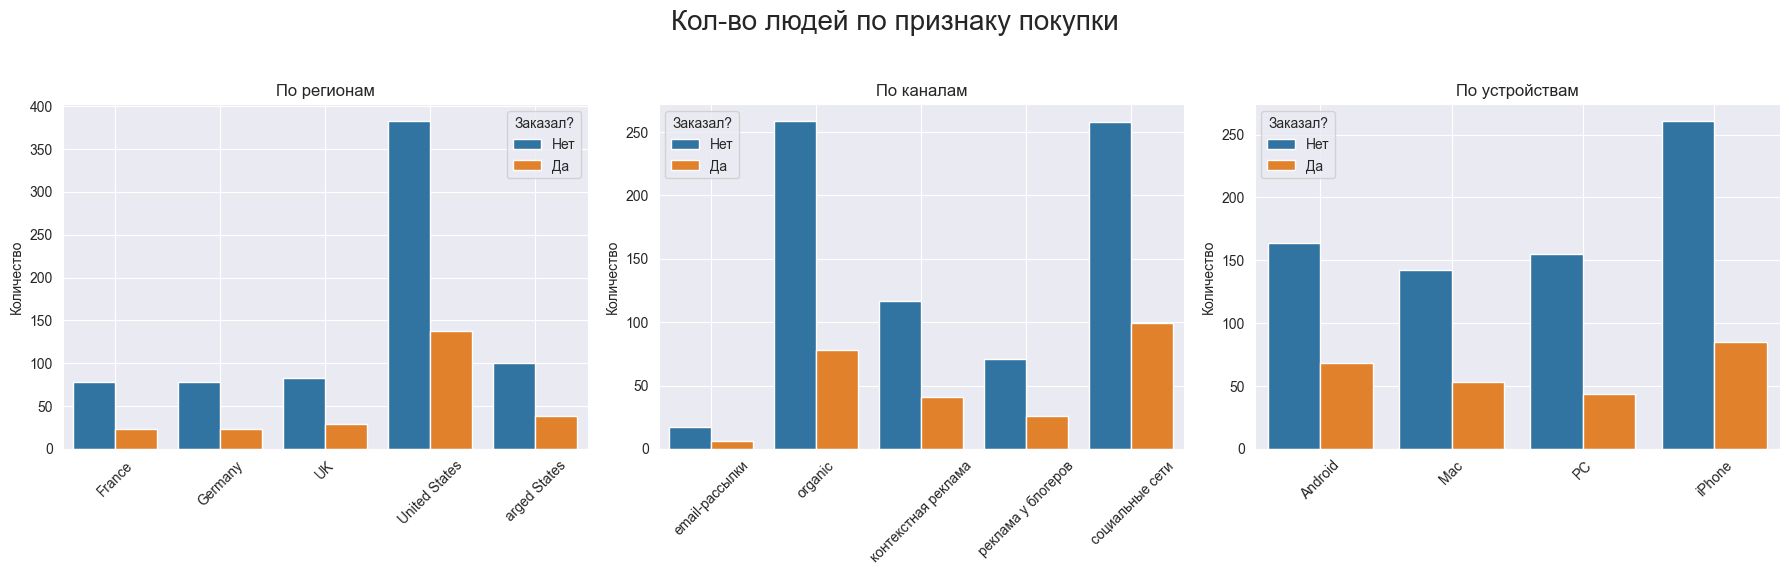

In [128]:
titles = ['По регионам', 'По каналам', 'По устройствам']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle('Кол-во людей по признаку покупки', fontsize=20)

for i, col in enumerate(['region', 'channel', 'device']):
    spec_data = data.groupby([col, 'payer'])['user_id'].count().reset_index()
    sns.barplot(data=spec_data, x=col, y='user_id', hue='payer', ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество')
    axes[i].set_axisbelow(True)

    handles, labels = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, ['Нет', 'Да'], title='Заказал?')

    axes[i].grid(True)
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

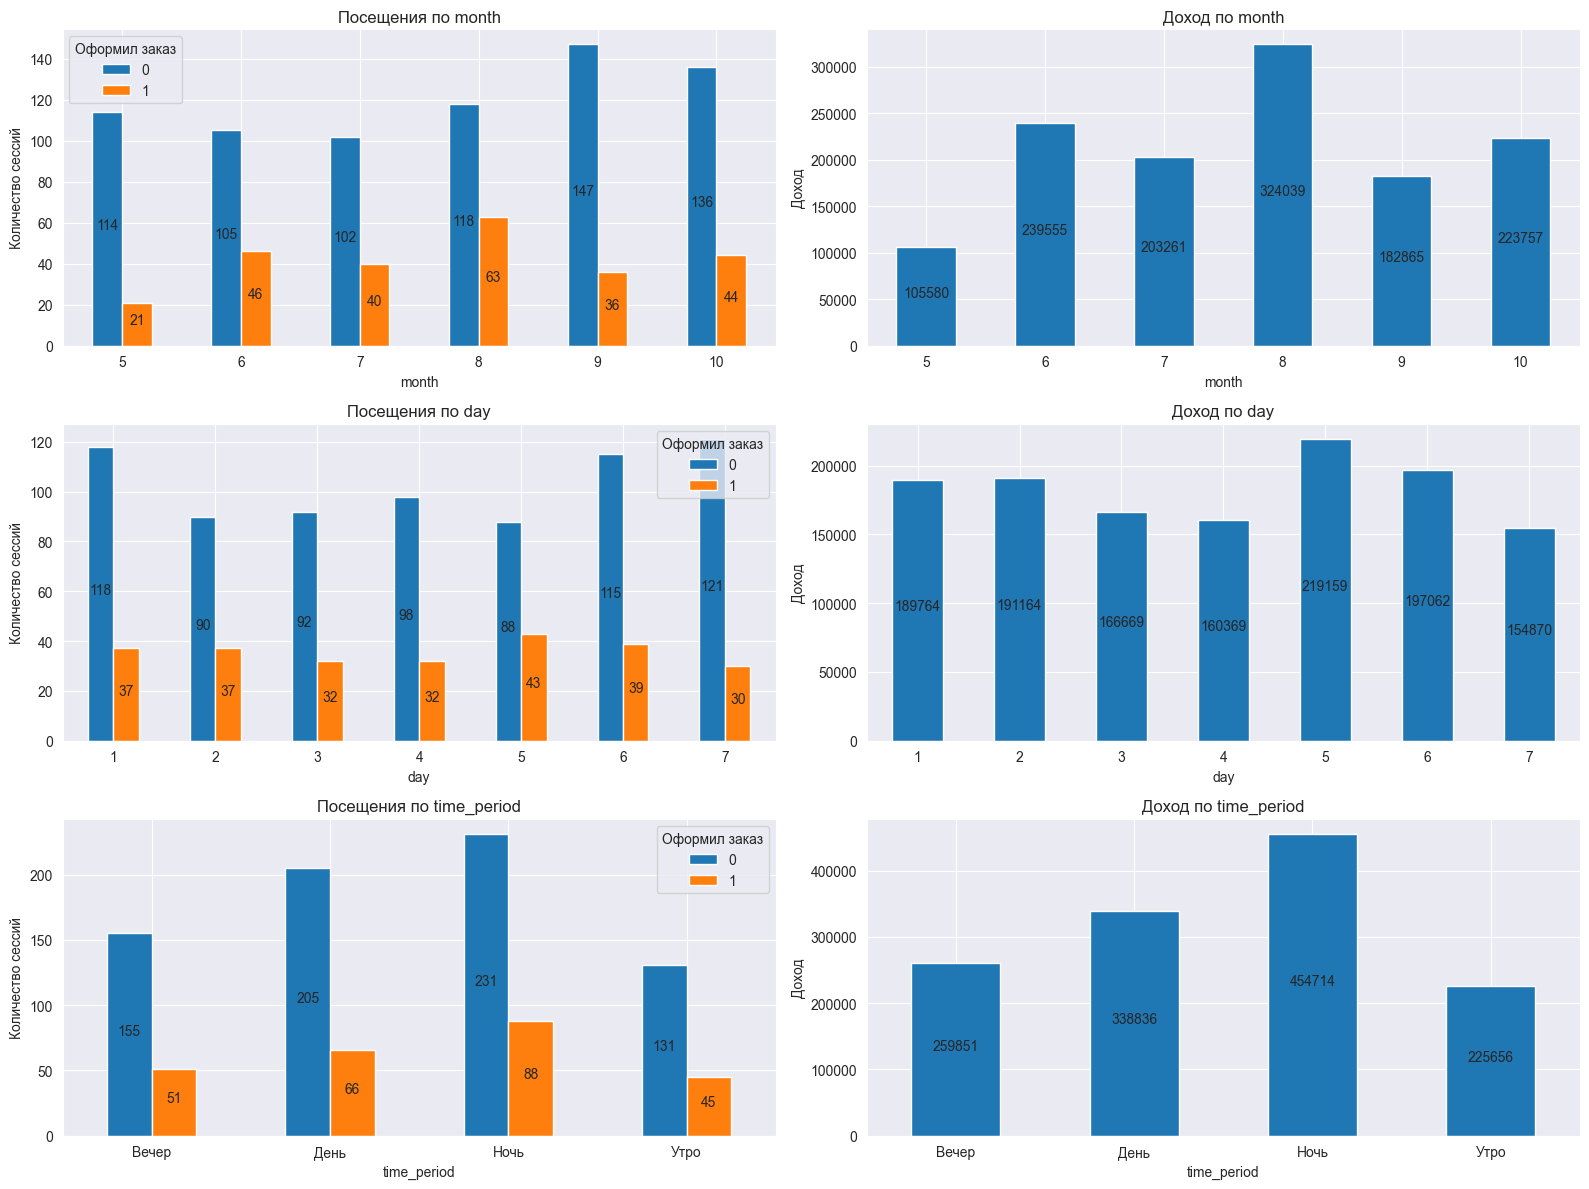

In [129]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i, arg in enumerate(['month', 'day', 'time_period']):
    A = data.groupby(arg)['payer'].value_counts().unstack(fill_value=0)
    A.plot(kind='bar', ax=axes[i, 0], rot=0)
    axes[i, 0].set_title(f'Посещения по {arg}')
    axes[i, 0].set_xlabel(arg)
    axes[i, 0].set_ylabel('Количество сессий')
    axes[i, 0].legend(title='Оформил заказ')

    for p in axes[i, 0].patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        axes[i, 0].annotate(f'{height:.0f}', (x + width/2, y + height/2), ha='center')

    B = data.groupby(arg)['final_price'].sum()
    B.plot(kind='bar', ax=axes[i, 1], rot=0)
    axes[i, 1].set_title(f'Доход по {arg}')
    axes[i, 1].set_xlabel(arg)
    axes[i, 1].set_ylabel('Доход')

    for p in axes[i, 1].patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        axes[i, 1].annotate(f'{height:.0f}', (x + width/2, y + height/2), ha='center')

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Количество покупок')

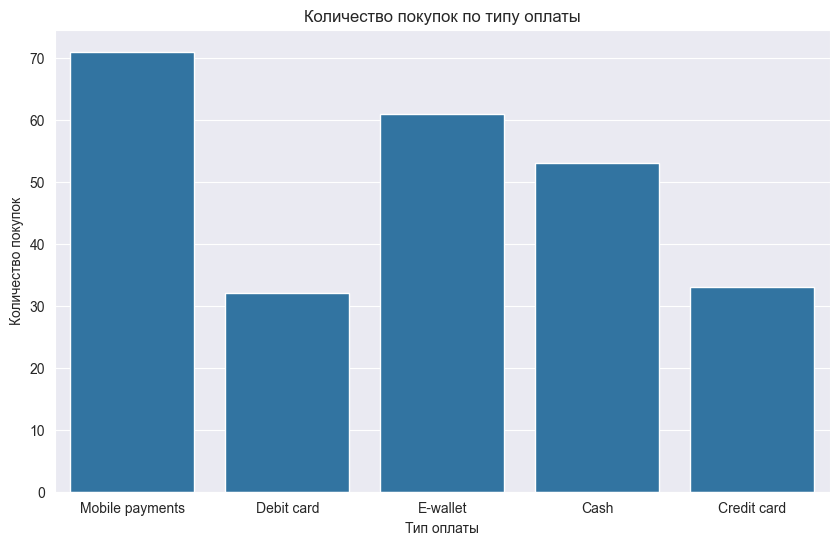

In [130]:
plt.figure(figsize=(10, 6))
sns.countplot(x='payment_type', data=data)
plt.title('Количество покупок по типу оплаты')
plt.xlabel('Тип оплаты')
plt.ylabel('Количество покупок')


In [131]:
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,europe,phone,payer,final_price,time_period
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,5,3,7,NaT,NaN,NaN,0.0,0,0,0,NaN,Утро
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,5,3,4,NaT,NaN,NaN,0.0,0,0,0,NaN,Ночь
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,5,3,18,NaT,NaN,NaN,0.0,0,1,0,NaN,Вечер
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,5,4,14,NaT,NaN,NaN,0.0,0,0,0,NaN,День
5,271758921583,United States,iPhone,социальные сети,2019-05-02 08:40:35,2019-05-02 08:41:15,40.000000,5,4,8,NaT,NaN,NaN,0.0,0,1,0,NaN,Утро
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,10,2,18,NaT,NaN,NaN,0.0,0,1,0,NaN,Вечер
1008,660140862425,Germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,10,3,19,NaT,NaN,NaN,0.0,1,1,0,NaN,Вечер
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,10,3,4,NaT,NaN,NaN,0.0,1,1,0,NaN,Ночь
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,10,4,23,NaT,NaN,NaN,0.0,0,1,0,NaN,Ночь


### Итог

**Удалено:** 39 строк (~3.85% датасета)

1) столбцы приведены к формату PEP8
2) удалены выбросы по цене товара и тех. ошибки в различных переменных (подробнее расписано при самом удалении)
3) исправлены дубликаты
4) в датасете представлены данные за 184 дня (183 days 22:49:37), рассматриваем весь период (зашкаливающие дни были выправлены после очистки выбросов в цене товара)
5) данные проверены на адекватность

    Примечание: имеются выбросы у длительности сессии, но причин удалять данные нет, т к они все в пределах адекатного (12 000 с = 3.33 ч, что вполне реально)

6) добавлены новые переменные и параметры для будущих расчётов (согласно ТЗ)
7) проведён графический анализ, выявлены возможные направления для будущих гипотез (см. подробнее в разделе "Гипотезы")

# Проведение расчетов

Рассчитываем средний чек, не берем в рассмотрение NaN

In [132]:
mean_buy = float(data['final_price'].mean())
mean_buy

5116.228

Рассчитываем, сколько покупок в среднем совершает 1 пользователь

In [133]:
un = data.groupby('user_id')['payer'].agg(sum)
float(un.mean())

0.257201646090535

Рассчитываем среднюю продолжительность сессии по рекламным каналам

In [134]:
def mean(data, group, group_name, col, col_name, agg='mean', agg_name='Среднее', top='max'):
    res = data.groupby(group)[col].agg(agg).reset_index().sort_values(by=col, ascending=False).reset_index(drop=True)

    to_print = f""
    if top == 'max':
        mx = res.shape[0]
        to_print = f"{col_name}, группируя по {group_name}"
    else:
        mx = top
        to_print = f"ТОП-{top} {col_name} по {group_name}"
    print(to_print)

    for i in range(mx):
        if isinstance(group, list):
            for j in group:
                print(f"{j}: {res.loc[i, j]}, ", end='')
            print(':', round(res.loc[i, col]))
        else:
            print(f"{res.loc[i, group]}: {round(res.loc[i, col])}")

    plot_data = res.iloc[:mx]

    plt.figure(figsize=(10, 5))

    if isinstance(group, list):
        plot_data['label'] = plot_data[group].astype(str).agg(' | '.join, axis=1)
        x = plot_data['label']
    else:
        x = plot_data[group]

    plt.bar(x, plot_data[col])

    plt.title(to_print)
    plt.ylabel(col_name)
    plt.xlabel(group_name)
    plt.xticks(rotation=0, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Рассчитываем среднюю продолжительность сессии по типу устройства.

Средняя продолжительность сессии клиента, группируя по тип устройтсва клиента
PC: 1938
Android: 1897
Mac: 1798
iPhone: 1726


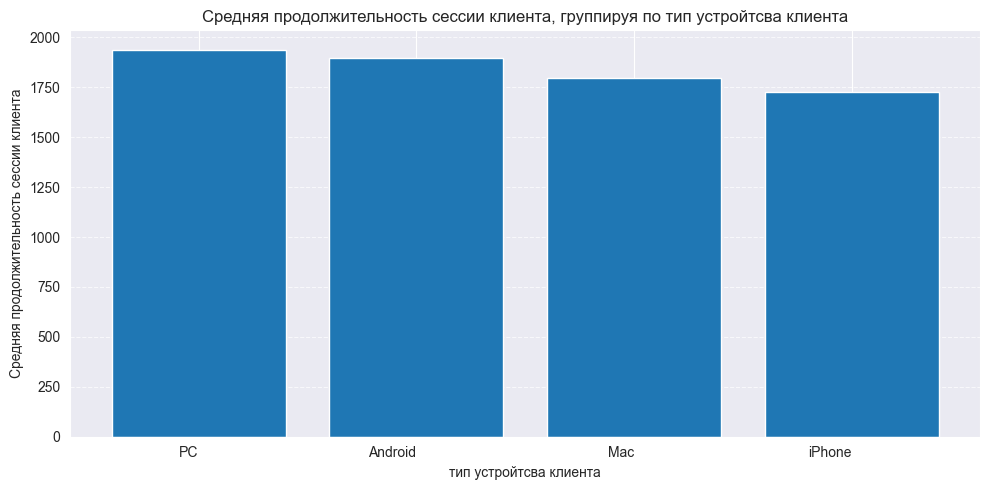

In [135]:
mean(data, 'device', 'тип устройтсва клиента', 'sessiondurationsec', 'Средняя продолжительность сессии клиента')

Рассчитываем топ-3 рекламных канала по среднему чеку.

ТОП-3 средняя сумма покупки по канал привлечения клиента
email-рассылки: 5499
реклама у блогеров: 5307
organic: 5268


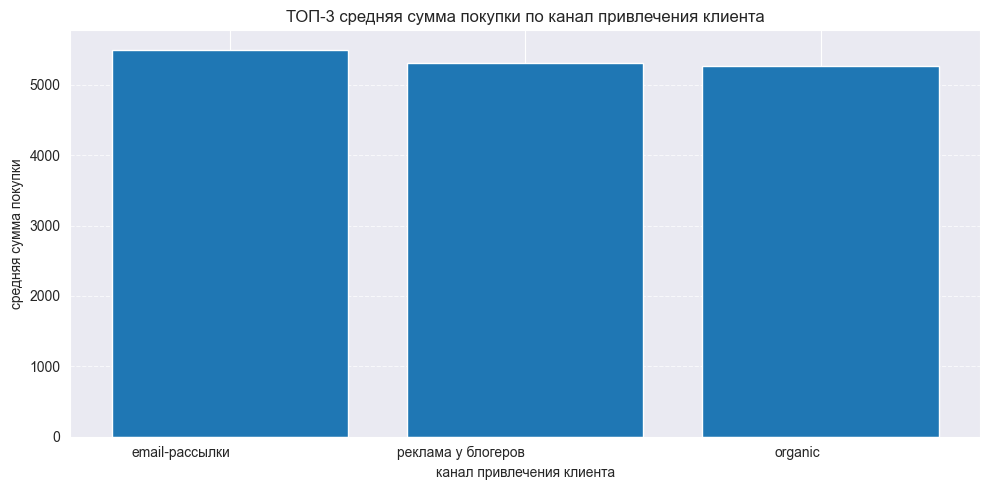

In [136]:
mean(data, 'channel', 'канал привлечения клиента', 'revenue', 'средняя сумма покупки', top=3)

Рассчитываем топ-3 региона по среднему чеку

ТОП-3 средняя сумма покупки по регион клиента
France: 5390
UK: 5344
arged States: 5315


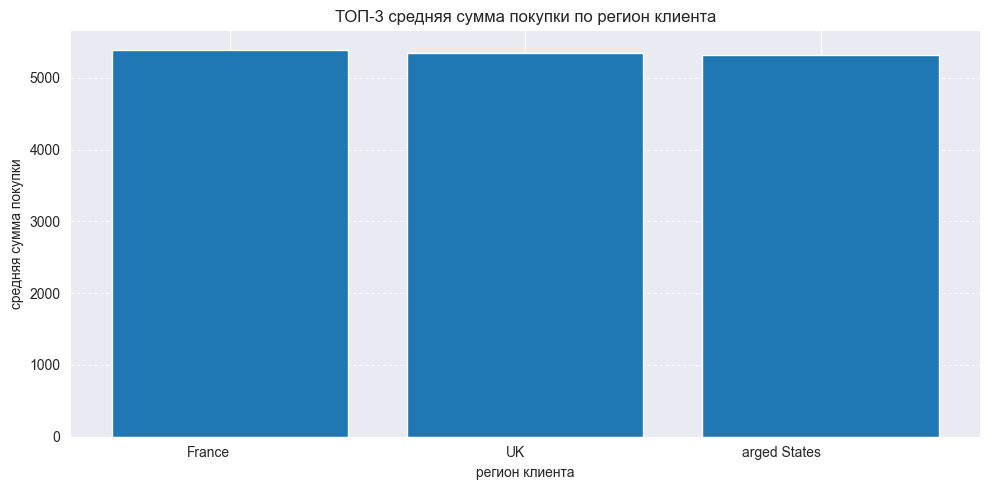

In [137]:
mean(data, 'region', 'регион клиента', 'revenue', 'средняя сумма покупки', top=3)

Рассчитываем топ-3 месяца по среднему чеку с разбивкой по регионам

ТОП-3 средняя сумма покупки по месяц и регион
month: 5, region: France, : 5999
month: 5, region: UK, : 5999
month: 6, region: Germany, : 5799


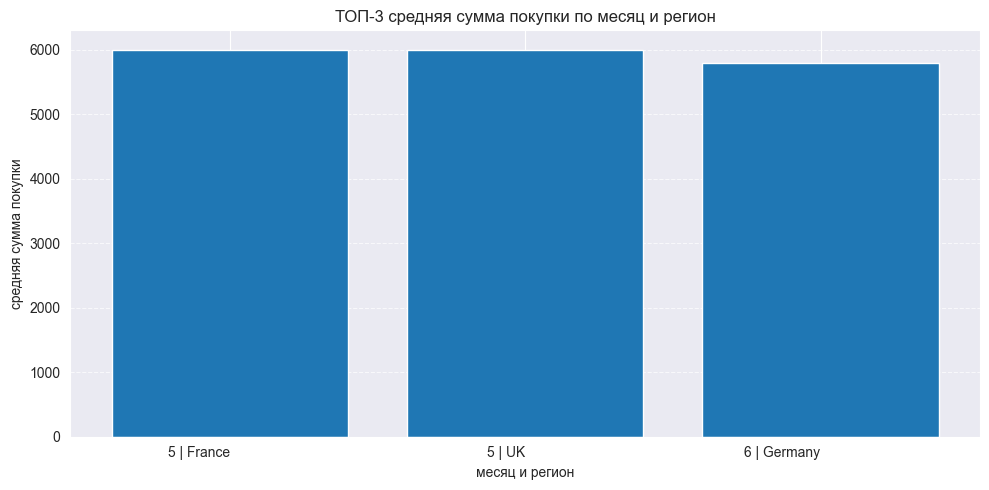

In [138]:
mean(data, ['month', 'region'], 'месяц и регион', 'revenue', 'средняя сумма покупки', top=3)

Рассчитываем MAU (Monthly Active Users) — это количество уникальных пользователей за месяц.

In [139]:
mau = data.groupby(['month', 'channel'])['user_id'].nunique().reset_index()
mau.columns = ['month', 'channel', 'mau']
mau

,month,channel,mau
0,5,email-рассылки,7
1,5,organic,73
2,5,контекстная реклама,8
3,5,реклама у блогеров,11
4,5,социальные сети,36
5,6,email-рассылки,1
6,6,organic,57
7,6,контекстная реклама,28
8,6,реклама у блогеров,13
9,6,социальные сети,52


In [140]:
mau_chan = data.groupby('channel')['user_id'].nunique().reset_index().sort_values(by='user_id', ascending=False).head(3)
mau_chan['user_id'] = mau_chan['user_id']/5
mau_chan.columns = ['channel', 'Среднее кол-во пользователей в месяц']
mau_chan

,channel,Среднее кол-во пользователей в месяц
4,социальные сети,71.4
1,organic,67.4
2,контекстная реклама,31.6


#### Общая таблица

In [141]:
channel_stats = data.groupby('channel').agg(
    total_visits=('user_id', 'count'),
    unique_users=('user_id', 'nunique'),
    payers=('payer', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()
channel_stats

,channel,total_visits,unique_users,payers,total_revenue
0,email-рассылки,23,23,6,32994.0
1,organic,337,337,78,410922.0
2,контекстная реклама,158,158,41,213959.0
3,реклама у блогеров,97,97,26,137974.0
4,социальные сети,357,357,99,519901.0


### Итог
**Вывод:** большее количество платящих пользователей и сумму продаж приносят социальные сети

# Гипотезы

#### Везде при проверке гипотез возьмем за критический уровень значимости - 5%

**Гипотеза**: средний чек отличается в зависимости от региона
- Нулевая гипотеза: регион **не влияет** на сумму чека
- Альтернативная гипотеза: регион **влияет** на сумму чека

Напишем общую функу с проверкой о различиях среднего чека. Чек - количественная величина, влияющие переменные - категориальные -> ANOVA или Критерий
Краскела-Уоллеса. Алгоритм функи:

С помощью теста Шапиро-Уиллка определяем нормальность данных.

- Данные распределены нормально:
  - проводим тест дисперсионного анализа ANOVA
  - p-value < 0.05:
    - Проводим пост-хок анализ - тест Тьюки-Крамера, для поиска групп, между которыми есть различия
- Данные распределены ненормально:
  - проводим тест Краскелла-Уоллиса
  - p-value < 0.05:
    - Проводим пост-хок анализ - тест Данна с поправкой Бонферрони, для поиска групп, между которыми есть различия

Строим гистограмму для наглядности.

In [142]:
from scipy.stats import shapiro, kruskal, fisher_exact
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp


def sr_chek_diff(data, col, col_name, y='revenue', y_name='средняя сумма покупки'):
    df = data.dropna(subset=[col, y])

    norm = True
    for i in df[col].unique():
        y_i = df[df[col] == i][y]
        if len(y_i) >= 3:
            stat, p = shapiro(y_i)
            if p < 0.05:
                norm = False

    y_groups = [df[df[col] == group][y] for group in df[col].unique()]
    if norm:
        print("ANOVA")
        stat, p = f_oneway(*y_groups)
        print(f"p-value = {p:.4f}")
        if p < 0.05:
            print("\nмежду группами есть различие. смотрим на разницу между каждыми группами (Тьюки-Крамер)")
            tukey = pairwise_tukeyhsd(endog=df[y], groups=df[col], alpha=0.05)
            print(tukey.summary())
        else:
            print("\nмежду группами нет различий.")
    else:
        print("Критерий Краскелла-Уоллиса")
        stat, p = kruskal(*y_groups)
        print(f"p-value = {p:.4f}")
        if p < 0.05:
            dunn_result = sp.posthoc_dunn(data, val_col=y, group_col=col, p_adjust='bonferroni')

            print("p-value с парными сравнениями (Dunn's Test с поправкой Бонферрони):\n")
            print(dunn_result.round(4))
        else:
            print("\nмежду группами нет различий.")

    fig = plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x=col, y=y, estimator='mean', ci='sd', edgecolor='black')
    plt.title(f"{y_name} по группам {col_name}")
    plt.xlabel(col_name)
    plt.ylabel(f"{y_name}")
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    fig.patch.set_facecolor('#F5F5F5')

    plt.tight_layout()
    plt.show()



Критерий Краскелла-Уоллиса
p-value = 0.1923

между группами нет различий.


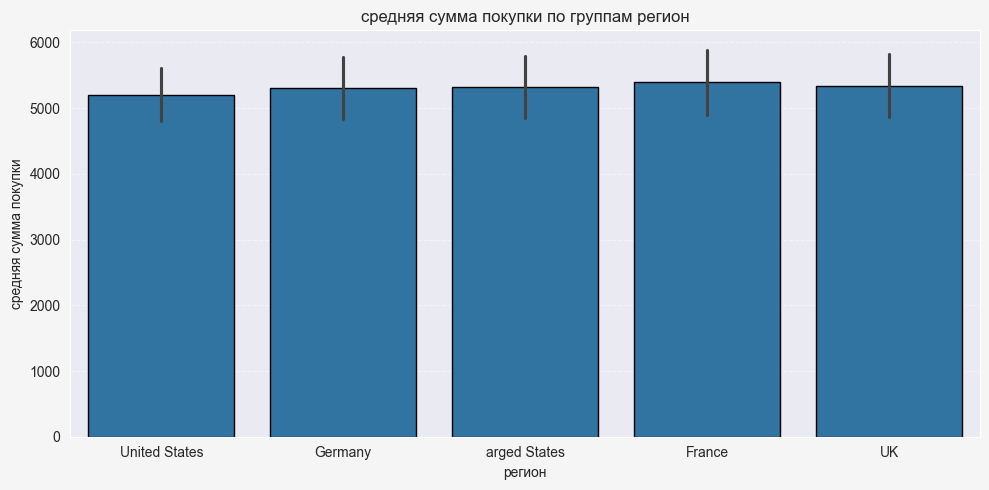

In [143]:
sr_chek_diff(data, 'region', 'регион', 'revenue', 'средняя сумма покупки')

P-value > 0.05 -> Альтернативная гипотеза отвергается -> регион не влияет на сумму чека.

**Гипотеза**: средний чек отличается в зависимости от рекламного канала.
- Нулевая гипотеза: Рекламный канал **не влияет** на сумму чека
- Альтернативная гипотеза: Рекламный канал **влияет** на сумму чека

Критерий Краскелла-Уоллиса
p-value = 0.6516

между группами нет различий.


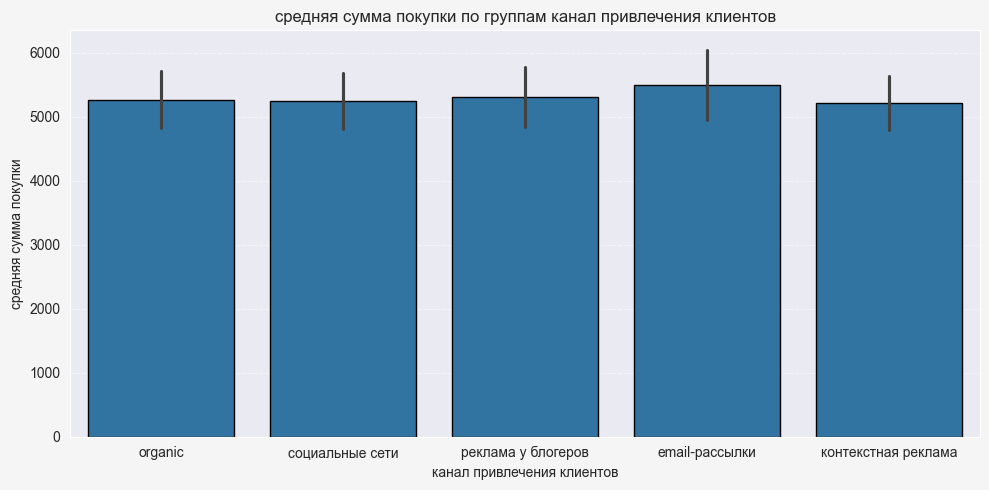

In [144]:
sr_chek_diff(data, 'channel', 'канал привлечения клиентов')

P-value > 0.05 -> Альтернативная гипотеза отвергается -> Тип рекламного канала не влияет на сумму чека.

**Гипотеза**: средний чек отличается в зависимости от времени суток
- Нулевая гипотеза: Время суток **не влияет** на сумму чека
- Альтернативная гипотеза: Время суток **влияет** на сумму чека

Критерий Краскелла-Уоллиса
p-value = 0.4650

между группами нет различий.


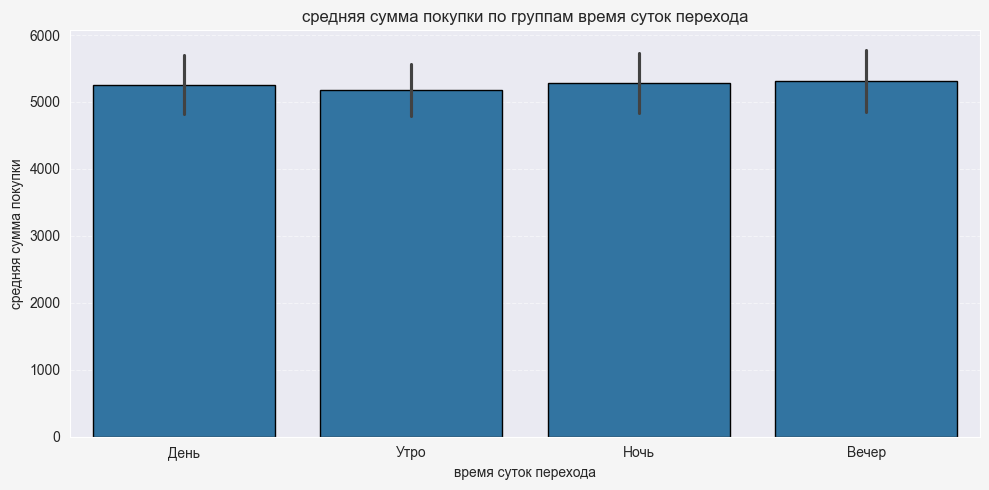

In [145]:
sr_chek_diff(data, 'time_period', 'время суток перехода')

P-value > 0.05 -> Различий не найдено

Гипотеза: Длительность сессии влияет на сумму покупок
- Нулевая гипотеза: между длительностью сессии и суммой покупок нет связи
- Альтернативная гипотеза: между длительностью сессии и суммой покупок нет связи

Длительность сессии и сумма - количественные переменные -> исследуем корреляцию.

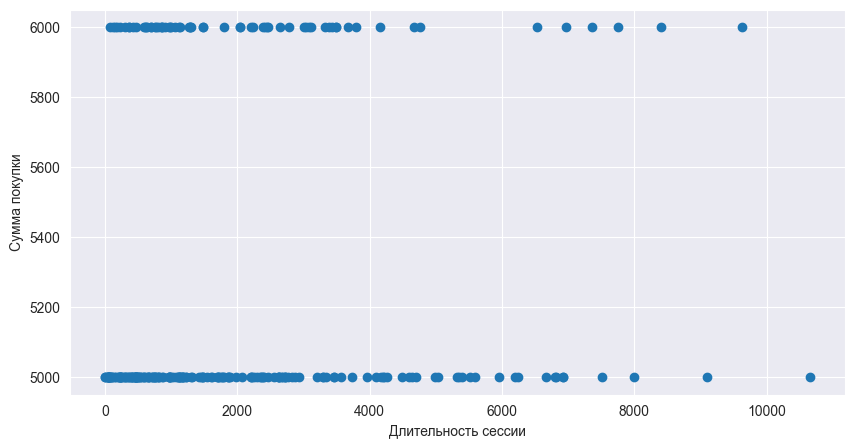

In [146]:
df = data.dropna(subset=['revenue', 'sessiondurationsec'])

plt.figure(figsize=(10, 5))
plt.scatter(df['sessiondurationsec'], df['revenue'])
plt.xlabel('Длительность сессии')
plt.ylabel('Сумма покупки')
plt.show()

На первый взгляд никакой взаимосвязи нет

Чтобы выбрать нужный метод, посмотрим на распределение данных

In [147]:
print('Тест на нормальность длительности', '\n', shapiro(data.dropna(subset=['revenue', 'sessiondurationsec'])['sessiondurationsec']))
print('Тест на нормальность суммы покупки', '\n', shapiro(data.dropna(subset=['revenue', 'sessiondurationsec'])['revenue']))

Тест на нормальность длительности 
 ShapiroResult(statistic=np.float64(0.8231127329646923), pvalue=np.float64(3.535625368591981e-16))
Тест на нормальность суммы покупки 
 ShapiroResult(statistic=np.float64(0.5498095324838077), pvalue=np.float64(6.380972644304744e-25))


P-value обеих переменных < 0.05 -> Данные распределены ненормально -> Тест Спирмана

In [148]:
from scipy.stats import spearmanr

revenue_sessiondurationsec = data.dropna(subset=['revenue', 'sessiondurationsec'])
corr, p_value = spearmanr(revenue_sessiondurationsec['sessiondurationsec'], revenue_sessiondurationsec['revenue'])
print(f"корреляция: {corr:.4f}")
print(f"p-value: {p_value:.4e}")

корреляция: 0.1039
p-value: 1.0134e-01


P-value > 0.05 -> Отвергаем альтернативную гипотезу -> связи между переменными нет:(

Вопрос: Влияет ли тип устройства на количество покупок в день по каждому региону?
Для ответа на вопрос для каждого региона исследуем, влияет ли тип устройства на payer.

_Гипотеза_: Тип устройства влияет на результат покупки
- Нулевая гипотеза: Тип устройства **не влияет** на результат покупки
- Альтернативная гипотеза: Тип устройства **влияет** на результат покупки

Построим логистическую регрессию. x - тип устройства (encoded), y - payer.

Делаем логрегу, категориальный столбец -> One hot Encoding, drop_first, чтобы избежать dummy trap

In [149]:
import statsmodels.api as sm


def logreg(data, x, y):
    X = pd.get_dummies(data[x], drop_first=True)
    X = X.astype(int)
    X = sm.add_constant(X)
    Y = data[y]
    model = sm.Logit(Y, X).fit()
    print(model.summary())

def logreg_by_region(data, x, y='payer', by='region', graphic=False):
    if by == 'skip':
        logreg(data, x, y)
    else:
        for uniq in data[by].unique():
            print(uniq, ':')
            logreg(data[data[by] == uniq], x, y)

    if graphic:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=data, x=x, y=y, estimator='mean', edgecolor='black')
        plt.title(f"среднее значение {y} по группам {x}")
        plt.xlabel(x)
        plt.ylabel(f"среднее {y}")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

In [150]:
logreg_by_region(data, 'device')

United States :
Optimization terminated successfully.
         Current function value: 0.575595
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  payer   No. Observations:                  520
Model:                          Logit   Df Residuals:                      516
Method:                           MLE   Df Model:                            3
Date:                Wed, 23 Apr 2025   Pseudo R-squ.:                0.001823
Time:                        23:28:15   Log-Likelihood:                -299.31
converged:                       True   LL-Null:                       -299.86
Covariance Type:            nonrobust   LLR p-value:                    0.7786
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8431      0.205     -4.110      0.000      -1.245      -0.441
Mac          

P-value всех девайсов во всех регионах > 0.05 -> Тип устройства не влияет на флаг покупки, а значит, не влияет на кол-во покупок в день

Влияет ли тип рекламного канала на количество покупок в день по каждому региону?
Алгоритм тот же
- Нулевая гипотеза: Тип рекламного канала **не влияет** на флаг покупки
- Альтернативная гипотеза: Тип рекламного канала **влияет** на флаг покупки

In [151]:
logreg_by_region(data, 'channel')

United States :
Optimization terminated successfully.
         Current function value: 0.574807
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  payer   No. Observations:                  520
Model:                          Logit   Df Residuals:                      516
Method:                           MLE   Df Model:                            3
Date:                Wed, 23 Apr 2025   Pseudo R-squ.:                0.003190
Time:                        23:28:15   Log-Likelihood:                -298.90
converged:                       True   LL-Null:                       -299.86
Covariance Type:            nonrobust   LLR p-value:                    0.5907
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.1197      0.168     -6.665      0.000      -1.44

P-value у всех типов рекламных источников во всех регионах > 0.05 -> Тип канала не влияет на флаг покупки, а значит, не влияет на кол-во покупок в день

#### Далее идут придуманные мною гипотезы

Гипотеза: Регион влияет на флаг покупки.
Также построим логрегу
- Нулевая гипотеза: Регион **не влияет** на флаг покупки
- Альтернативная гипотеза: Регион **влияет** на флаг покупки

Optimization terminated successfully.
         Current function value: 0.569448
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  payer   No. Observations:                  972
Model:                          Logit   Df Residuals:                      967
Method:                           MLE   Df Model:                            4
Date:                Wed, 23 Apr 2025   Pseudo R-squ.:                0.001160
Time:                        23:28:15   Log-Likelihood:                -553.50
converged:                       True   LL-Null:                       -554.15
Covariance Type:            nonrobust   LLR p-value:                    0.8637
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2212      0.237     -5.147      0.000      -1.686      -0.756
Germany       -2.549

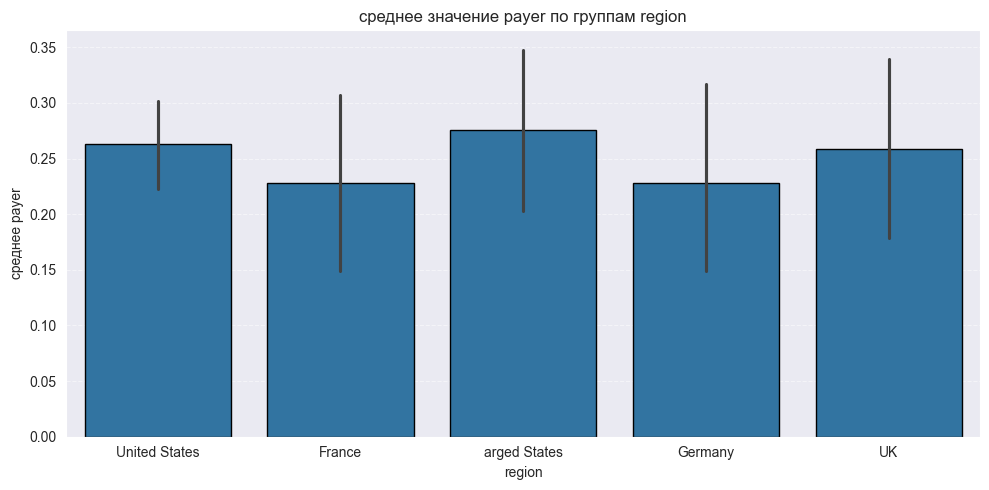

In [152]:
logreg_by_region(data, 'region', by='skip', graphic=True)

P-value у всех регионов > 0.05 -> Регион не влияет на флаг покупки

Гипотеза: Время перехода влияет на покупку.

- Нулевая гипотеза: Время перехода **не влияет** на флаг покупки
- Альтернативная гипотеза: Время перехода **влияет** на флаг покупки

Optimization terminated successfully.
         Current function value: 0.569624
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  payer   No. Observations:                  972
Model:                          Logit   Df Residuals:                      968
Method:                           MLE   Df Model:                            3
Date:                Wed, 23 Apr 2025   Pseudo R-squ.:               0.0008512
Time:                        23:28:16   Log-Likelihood:                -553.67
converged:                       True   LL-Null:                       -554.15
Covariance Type:            nonrobust   LLR p-value:                    0.8150
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1116      0.161     -6.886      0.000      -1.428      -0.795
День          -0.0218      0.

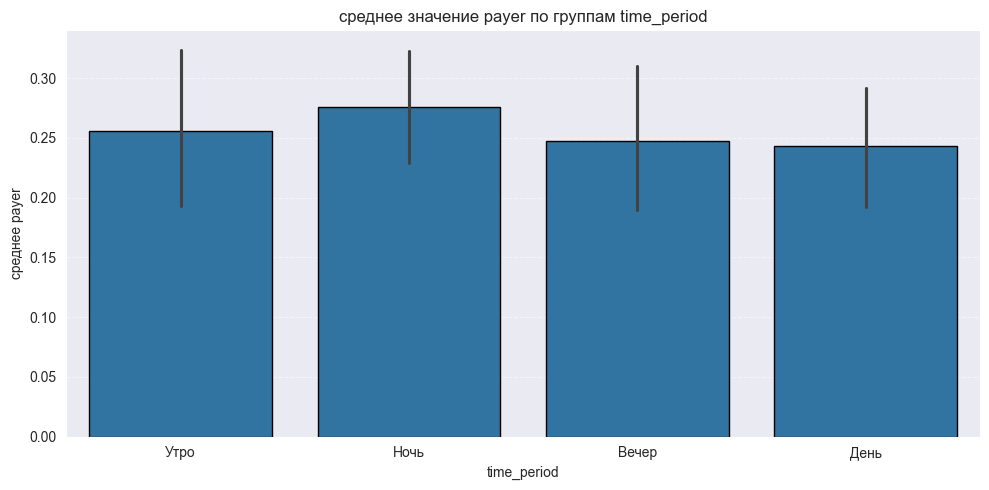

In [153]:
logreg_by_region(data, 'time_period', by='skip', graphic=True)

P-value у всех времен дня > 0.05 -> Время дня не влияет на флаг покупки

Рассмотрим, как зависит payer от дня недели

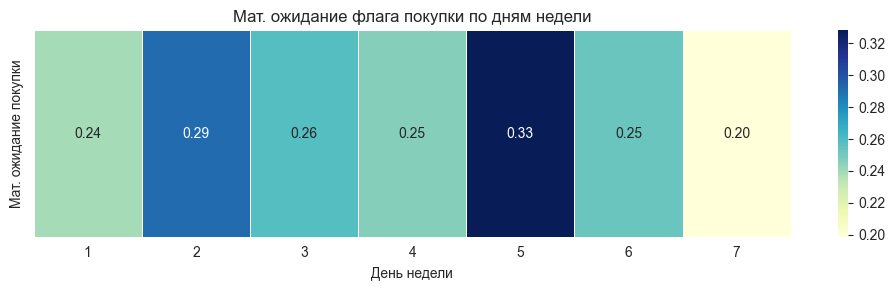

In [154]:
pivot_table = data[['day', 'payer']].groupby('day')['payer'].agg('mean').to_frame().T
pivot_table.index = ['Мат. ожидание покупки']

plt.figure(figsize=(10, 3))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5)
plt.title("Мат. ожидание флага покупки по дням недели")
plt.xlabel("День недели")
plt.ylabel("")
plt.tight_layout()
plt.show()

Отсюда гипотеза: По пятницам процент успешных покупок больше
- Нулевая гипотеза: Пятница **не влияет** на флаг покупки
- Альтернативная гипотеза: Пятница **влияет** на флаг покупки

Рассматриваем влияние бинарной переменной на бинарную -> Хи-квадрат

In [155]:
data['date'] = pd.to_datetime(data['session_start'].dt.date)
data['is_friday'] = data['day'].isin([5]).astype(int)

In [156]:
purchase_rate = data.groupby('is_friday')['payer'].mean().reset_index()
purchase_rate.columns = ['is_friday', 'purchase_probability']
print(purchase_rate)

contingency = pd.crosstab(data['is_friday'], data['payer'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

   is_friday  purchase_probability
0          0              0.246136
1          1              0.328244
p-value: 0.05842511284344329


P-value > 0.05 -> Отвергаем альтернативную гипотезу -> различий между группами нет.

Посмотрим, почему так происходит.

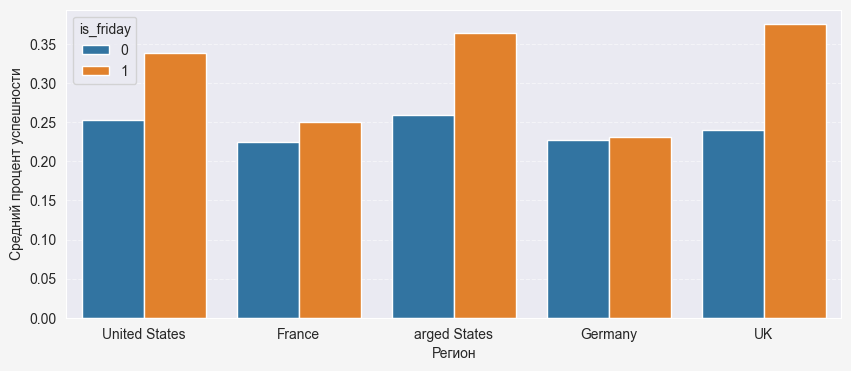

In [157]:
fig = plt.figure(figsize=(10, 4))
sns.barplot(data=data, x='region', y='payer', hue='is_friday', estimator='mean', ci=None)
plt.xticks(rotation=0)
plt.xlabel('Регион')
plt.ylabel('Средний процент успешности')
plt.grid(axis='y', linestyle='--', alpha=0.5)
fig.patch.set_facecolor('#F5F5F5')
plt.show()

видно, что Франция и Германия меньше подчиняются гипотезе:)
Тогда уточним гипотезу на остальные регионы рекламы

In [158]:
purchase_rate = data[data['region'].isin(['UK', 'arged States'])].groupby('is_friday')['payer'].mean().reset_index()
purchase_rate.columns = ['is_friday', 'purchase_probability']
print(purchase_rate)

contingency = pd.crosstab(data[data['region'].isin(['UK', 'arged States'])]['is_friday'], data[data['region'].isin(['UK', 'arged States'])]['payer'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

   is_friday  purchase_probability
0          0              0.250000
1          1              0.368421
p-value: 0.1872127088205657


P-value < 0.05 -> Результат значимый. Отвергаем нулевую гипотезу. Пятница влияет на результат. Процент в пятницу: 35%, не в пятницу: 25%

Отсюда можно сделать вывод: Для регионов USA и UK нужно больше инвестировать в рекламу по пятницам (например, покупать рекламу у блогеров, делающих посты по пятницам)

Исследуем, как зависит payer от месяца

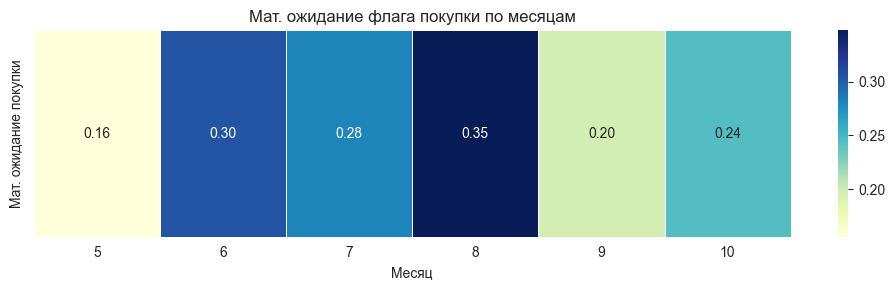

In [159]:
pivot_table = data[['month', 'payer']].groupby('month')['payer'].agg('mean').to_frame().T
pivot_table.index = ['Мат. ожидание покупки']

plt.figure(figsize=(10, 3))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5)
plt.title("Мат. ожидание флага покупки по месяцам")
plt.xlabel("Месяц")
plt.ylabel("")
plt.tight_layout()
plt.show()

Видно, что в летние месяца успешность больше. Отсюда гипотеза: Летом процент покупок больше

- Нулевая гипотеза: Лето **не влияет** на результат.
- Альтернативная гипотеза: Лето **влияет** на результат.

рассматриваем влияние бинарной переменной на бинарную -> Хи-квадрат

In [160]:
data['is_summer'] = data['month'].isin([6, 7, 8])
purchase_rate = data.groupby('is_summer')['payer'].mean().reset_index()
purchase_rate.columns = ['is_summer', 'purchase_probability']
print(purchase_rate)

contingency = pd.crosstab(data['is_summer'], data['payer'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Статистика хи-квадрат:", chi2)
print("p-value:", p)

   is_summer  purchase_probability
0      False              0.202811
1       True              0.314346
Статистика хи-квадрат: 15.234689896441905
p-value: 9.494328802818055e-05


P-value < 0.05 -> Отвергаем нулевую гипотезу -> Летом процент успешных песещений сайта (31,5%) больше чем не летом (20,2%)

Применение: летом вкладываться в рекламу больше, чем осенью или весной.

In [161]:
df = data[data['channel'] != 'organic'][data['time_period'].isin(["Вечер"])].copy()
df['flag'] = (df['day'].isin([5, 6])).astype(int)

contingency = pd.crosstab(df['flag'], df['payer'])
# stat, p = fisher_exact(contingency, alternative='less')
stat, p, dof, expected = chi2_contingency(contingency)

print("Статистика хи-квадрат:", stat)
print("p-value:", p)

Статистика хи-квадрат: 3.9665570378140727
p-value: 0.046412579458321446


In [162]:
data['channel'].unique()

array(['organic', 'социальные сети', 'реклама у блогеров',
       'контекстная реклама', 'email-рассылки'], dtype=object)

In [163]:
data['fast_reklama'] = (data['channel'].isin(['социальные сети', 'контекстная реклама'])).astype(int)

# 'социальные сети' и 'контекстная реклама' я объединил в категорию "быстрая реклама".
# Причина: пользователь изначально не заходит в соцсети или поисковик ради рекламы,
# но часто сталкивается с ней в процессе просмотра контента.
# Это делает контакт с рекламой спонтанным и частым.
# В отличие от email-рассылок, где человек целенаправленно ожидает маркетинговые предложения.
# Блогеров люди относительно мало смотрят, т.к. на каждое видео выделяется много времени,
# поэтому к быстрой рекламе я такую категорию не относил

Исследуем, как быстрая реклама влияет на результат

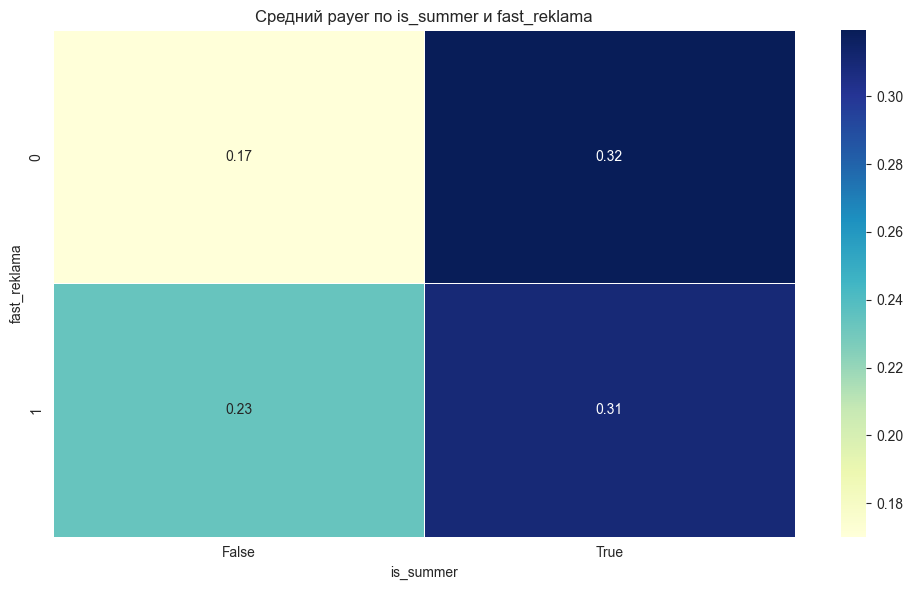

In [164]:
pivot_table = data[['fast_reklama', 'is_summer', 'payer']].groupby(['fast_reklama', 'is_summer'])['payer'].agg('mean').unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5)

plt.title(f"Средний payer по is_summer и fast_reklama")
plt.xlabel("is_summer")
plt.ylabel('fast_reklama')
plt.tight_layout()
plt.show()

Видно, что летом быстрая реклама почти не влияет на результат, а в нелетнее время - сильнее.

Отсюда гипотеза: В нелетнее время с помощью быстрой рекламы чаще покупают.
- Нулевая гипотеза: быстрая реклама **не влияет** на результат
- Альтернативная гипотеза: быстрая реклама **влияет** на результат

In [165]:
df = data[data['is_summer'] == 0].copy()
contingency = pd.crosstab(df['fast_reklama'], df['payer'])
stat, p, dof, expected = chi2_contingency(contingency)
print(p)

0.09992537220779389


P-value > 0.05 -> Гипотеза не значима. Присмотримся повнимательнее

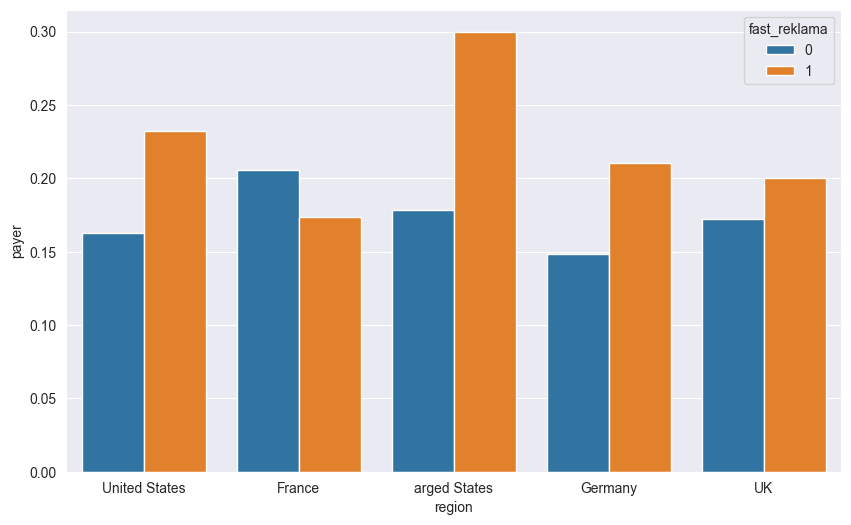

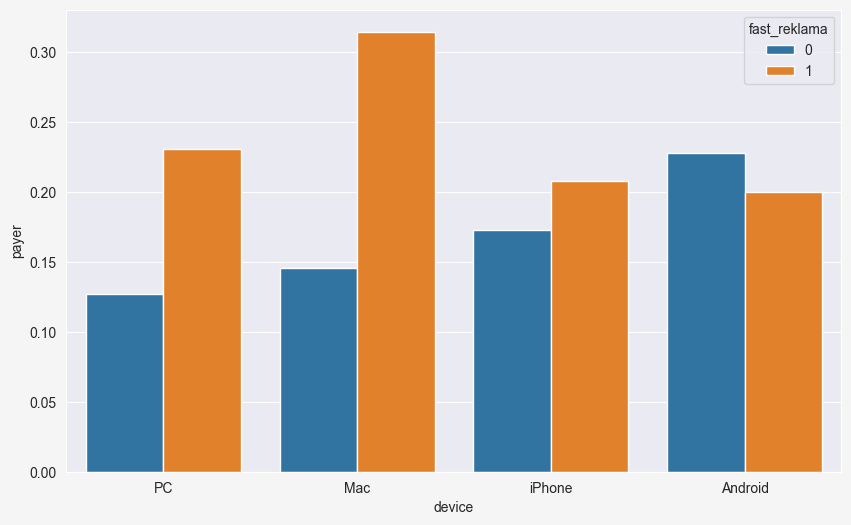

In [166]:
plt.figure(figsize=(10, 6))
sns.barplot(data=data[data['is_summer'] == 0], x='region', y='payer', hue='fast_reklama', estimator='mean', ci=None)
plt.show()

fig = plt.figure(figsize=(10, 6))
sns.barplot(data=data[data['is_summer'] == 0], x='device', y='payer', hue='fast_reklama', estimator='mean', ci=None)
fig.patch.set_facecolor('#F5F5F5')
plt.show()

Видно, что гипотеза не работает для Франции и для пользователей Андроидов. Уточним гипотезу.

В нелетнее время пользователи PC, Mac и iPhone, живущие в USA, UK и Германии с помощью быстрой рекламы чаще покупают.
- Нулевая гипотеза: быстрая реклама **не влияет** на результат
- Альтернативная гипотеза: быстрая реклама **влияет** на результат

In [167]:
df = data[data['is_summer'] == 0][data['region'] != 'France'][data['device'] != 'Android'].copy()
contingency = pd.crosstab(df['fast_reklama'], df['payer'])
stat, p, dof, expected = chi2_contingency(contingency)
print(p)

0.03776540409543291


In [168]:
contingency

payer,0,1
fast_reklama,,
0,137,24
1,139,45


P-value < 0.05 -> Отвергаем нулевую гипотезу -> быстрая реклама влияет на результат.

## Выводы из гипотез

Что влияет на сумму покупки?
- Регион не влияет на сумму покупки
- Тип рекламного канала не влияет на сумму покупки
- Время суток не влияет на сумму покупки
- Длительность сессии не влияет на сумму покупки

Что влияет на кол-во покупок в день?
- Тип устройства не влияет на кол-во покупок в день
- Тип канала не влияет на кол-во покупок в день

Что влияет на флаг покупки?
- Регион не влияет на флаг покупки
- Время суток не влияет на флаг покупки

Сложные гипотезы
- Регионы USA и UK имеют больший процент завершенных покупок по пятницам
- Летом люди имеют больший процент завершенных покупок
- В нелетнее время пользователи PC, Mac и iPhone, живущие в USA, UK и Германии имеют больший процент завершенных покупок с помощью 'социальные сети' и 'контекстная реклама’.

**Рекомендации**
- Концентрировать рекламу пользователям из USA и UK по Пятницам
- Концентрировать рекламу на лето
 - Осенью и весной в пользователям PC, Mac и iPhone, живущих в USA, UK и Германии концентрировать рекламу на ‘социальные сети' и 'контекстная реклама’.

Графики к трем последним гипотезам

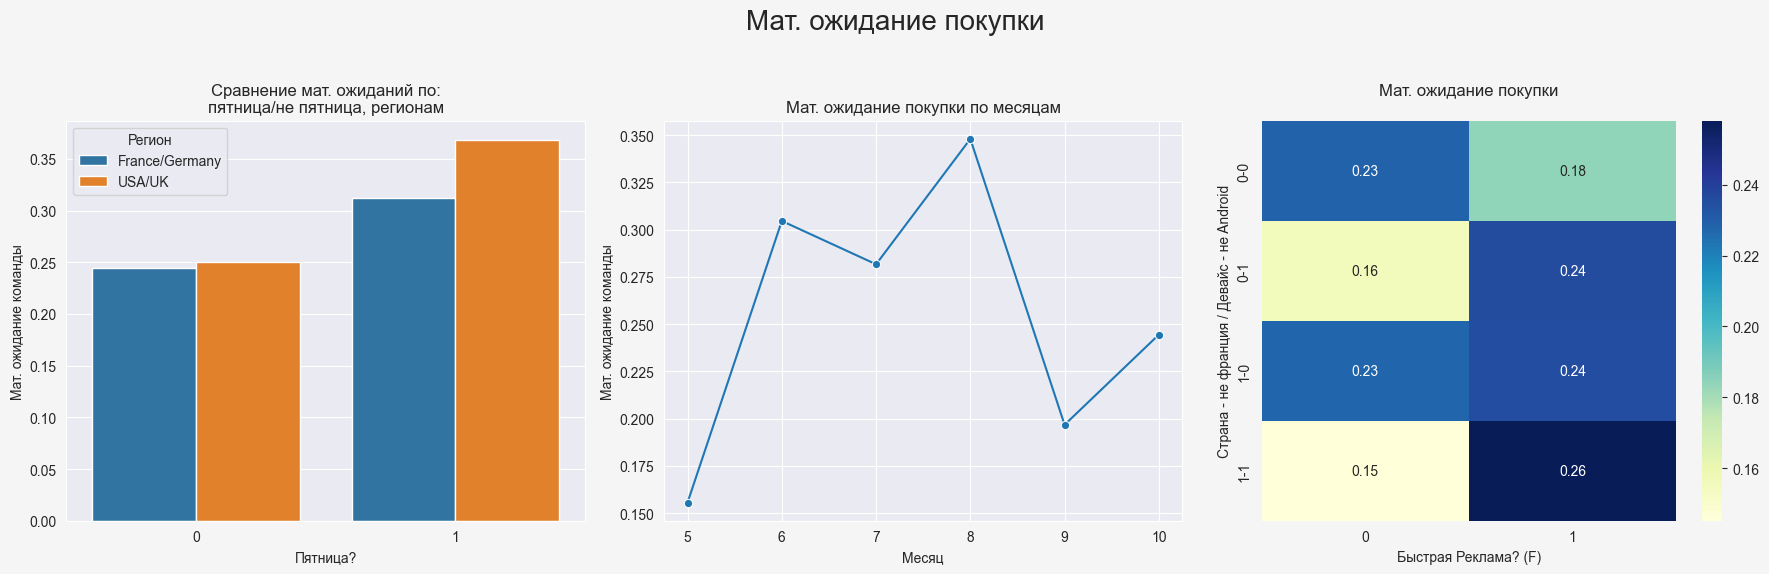

In [169]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Мат. ожидание покупки', fontsize=20)

data['region_group'] = data['region'].apply(lambda x: 'USA/UK' if x in ['arged States', 'UK'] else 'France/Germany')
friday_group = data.groupby(['is_friday', 'region_group'])['payer'].mean().reset_index()

sns.barplot(data=friday_group, x='is_friday', y='payer', hue='region_group', ax=axes[0])
axes[0].set_title('Сравнение мат. ожиданий по:\nпятница/не пятница, регионам')
axes[0].set_xlabel('Пятница?')
axes[0].set_ylabel('Мат. ожидание команды')
axes[0].legend(title='Регион')

month_group = data.groupby('month')['payer'].mean().reset_index()
sns.lineplot(data=month_group, x='month', y='payer', marker='o', ax=axes[1])
axes[1].set_title('Мат. ожидание покупки по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Мат. ожидание команды')
axes[1].grid(True)

data['flag_country'] = data['region'].apply(lambda x: 1 if x in ['arged States', 'UK', 'Germany'] else 0)
data['flag_device'] = data['device'].apply(lambda x: 1 if x in ['PC', 'Mac', 'iPhone'] else 0)

heatmap_data = data[data['is_summer'] == 0].groupby(['flag_country', 'flag_device', 'fast_reklama'])['payer'].mean().reset_index()
pivot_table = heatmap_data.pivot_table(index=['flag_country', 'flag_device'], columns='fast_reklama', values='payer')

sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[2])
axes[2].set_title('Мат. ожидание покупки\n')
axes[2].set_xlabel('Быстрая Реклама? (F)')
axes[2].set_ylabel('Страна - не франция / Девайс - не Android')

fig.patch.set_facecolor('#F5F5F5')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [170]:
data['region'].unique()

array(['United States', 'France', 'arged States', 'Germany', 'UK'],
      dtype=object)

# Моделирование

Целевая переменная - payer - флаг покупки. Перед моделированием посмотрим на корреляцию между переменными. Корреляция от payer считаем так: второй столбец количественный -> отношение дисперсий, категориальный -> Хи-квадрат

In [171]:
def plot_correlation_heatmap(matrix):
    binary = [
        'is_friday', 'region_France', 'region_Germany', 'region_UK', 'region_arged States',
        'device_Mac', 'device_Android', 'device_PC', 'device_iPhone', 'channel_organic',
        'channel_контекстная реклама', 'channel_реклама у блогеров',
        'channel_социальные сети', 'channel_email-рассылки', 'time_period_День', 'time_period_Ночь',
        'time_period_Утро', 'time_period_Ночь'
    ]

    columns = matrix.columns
    result = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                result.loc[col1, col2] = 1.0  # корреляция с собой
                continue

            if 'payer' in (col1, col2):
                other = col2 if col1 == 'payer' else col1
                if other in binary:
                    contingency = pd.crosstab(matrix['payer'], matrix[other])
                    chi2, p, _, _ = chi2_contingency(contingency)
                    result.loc[col1, col2] = 1 - p
                else:
                    payer_1 = matrix[matrix['payer'] == 1][other].dropna()
                    payer_0 = matrix[matrix['payer'] == 0][other].dropna()

                    var_ratio = np.var(payer_1, ddof=1) / np.var(payer_0, ddof=1)
                    log_ratio = np.log2(var_ratio)
                    normalized = np.tanh(log_ratio)
                    result.loc[col1, col2] = normalized

            else:
                corr = matrix[col1].corr(matrix[col2])
                result.loc[col1, col2] = corr

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(result.astype(float), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, ax=ax)
    ax.set_title("Комбинированная матрица связей (Корреляция / Хи-квадрат / Отношение дисперсий)", fontsize=14)
    fig.patch.set_facecolor('#F5F5F5')
    plt.tight_layout()
    plt.show()


In [172]:
data_clean = data.drop(columns=[
    'user_id', 'order_dt', 'revenue', 'payment_type',
    'promo_code', 'europe', 'phone', 'final_price',
    'session_start', 'session_end', 'date'
]).dropna()

categorical_columns = ['region', 'device', 'channel', 'time_period']
X = pd.get_dummies(data_clean, columns=categorical_columns) # One-hot-encoding
X = X.select_dtypes(include=['int64', 'float64', 'uint8', 'bool']).astype(float)
X = sm.add_constant(X)

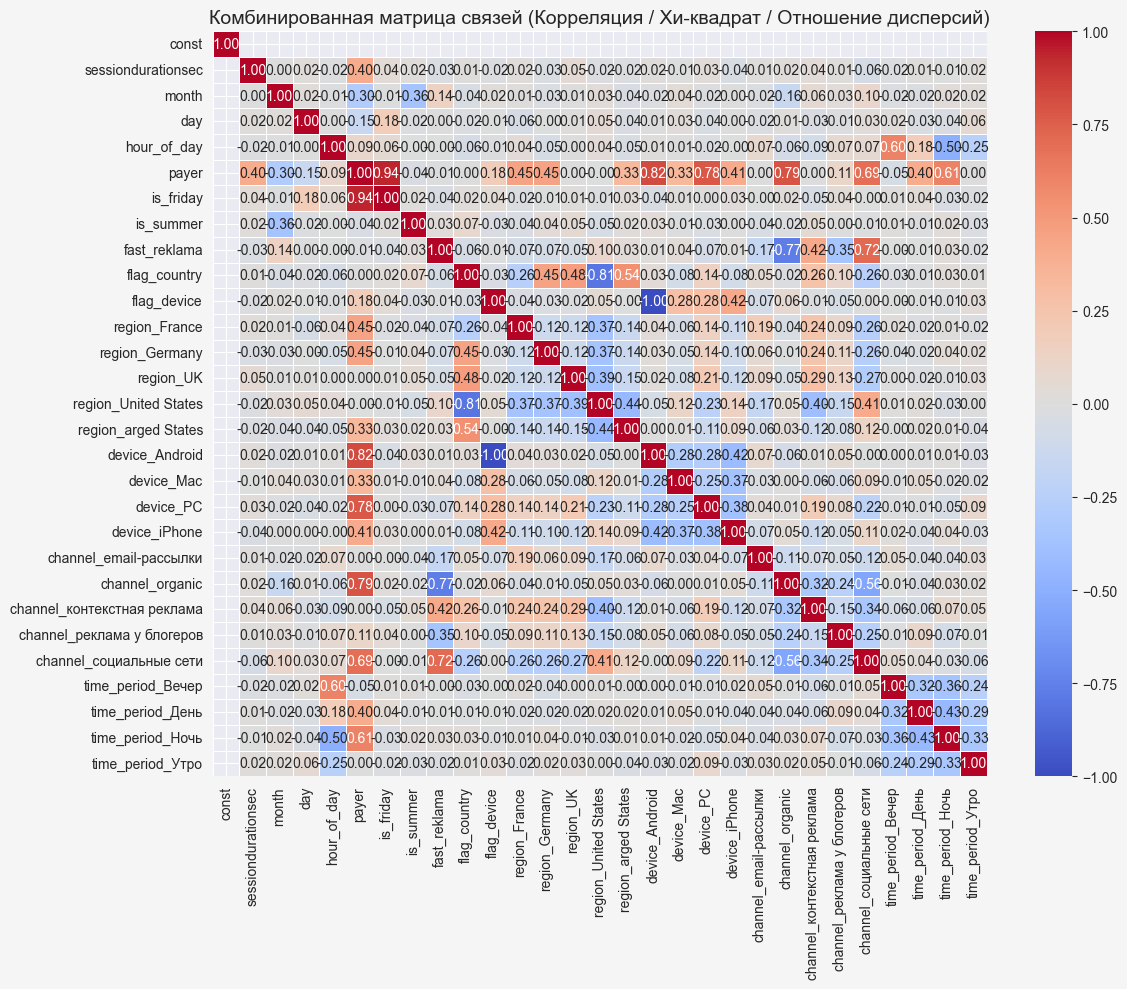

In [173]:
plot_correlation_heatmap(X)

Оставим только те столбцы, которые влияют на payer. Также удалим по одному столбцу из всех декодированных столбцов, чтобы избежать dummy trap

In [174]:
X = X[['const', 'sessiondurationsec', 'month',
       'is_friday', 'region_France', 'region_Germany', 'region_arged States',
       'device_Android', 'device_PC', 'channel_organic', 'channel_социальные сети',
       'time_period_День', 'time_period_Ночь', 'payer']]

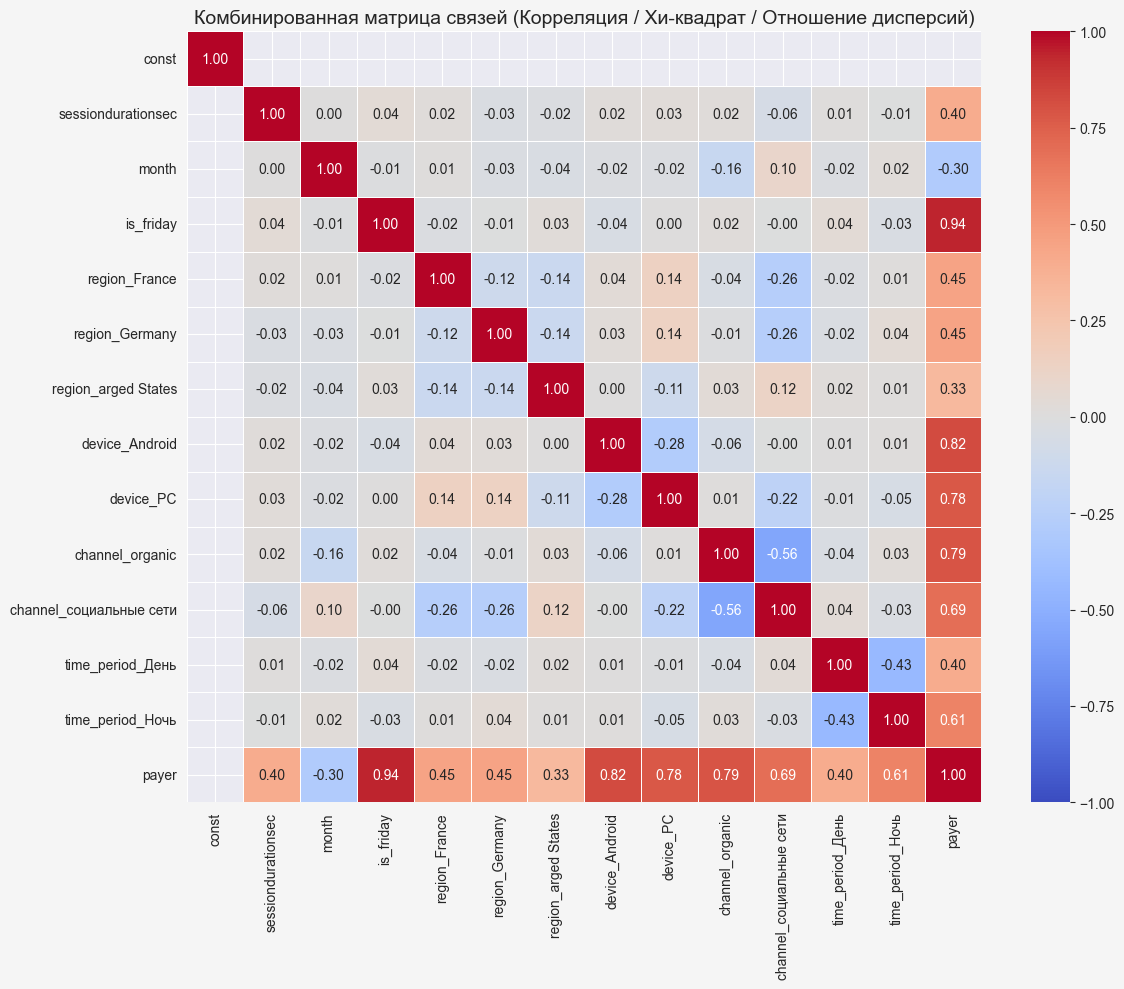

In [175]:
plot_correlation_heatmap(X)

Видим, что мультиколлинеарности не возникает.

In [176]:
y = X['payer']
X.drop('payer', inplace=True, axis=1)
model = sm.Logit(y, X).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.562944
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  payer   No. Observations:                  972
Model:                          Logit   Df Residuals:                      959
Method:                           MLE   Df Model:                           12
Date:                Wed, 23 Apr 2025   Pseudo R-squ.:                 0.01257
Time:                        23:28:26   Log-Likelihood:                -547.18
converged:                       True   LL-Null:                       -554.15
Covariance Type:            nonrobust   LLR p-value:                    0.3052
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.1963      0.424     -2.819      0.005      -2.028   

Видим, что при обучении логистической регрессии p-value почти всех переменных > 0.05 -> Модель неточная, для точности позже обучим CatBoost.

Графически отобразим влияние переменных

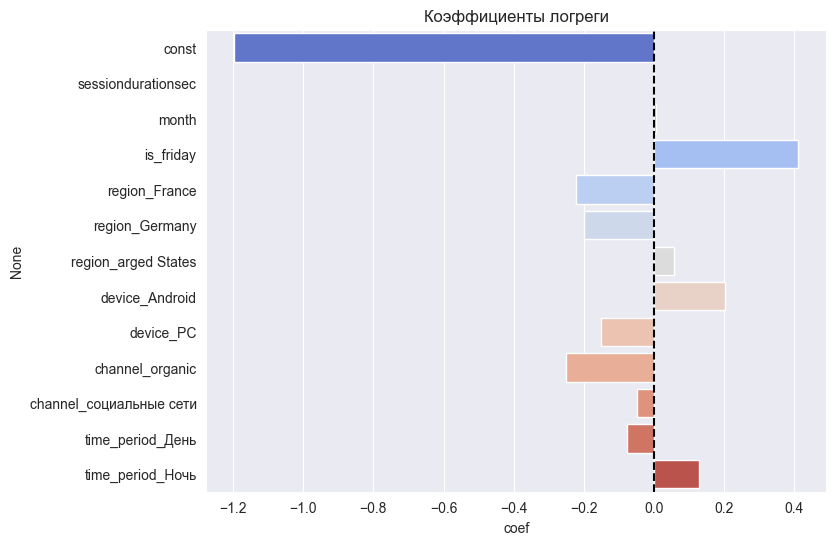

In [177]:
coefs = model.params
conf = model.conf_int()
conf.columns = ['2.5%', '97.5%']
coef_df = pd.concat([coefs, conf], axis=1).rename(columns={0: 'coef'})

# сам график
plt.figure(figsize=(8,6))
sns.barplot(
    y=coef_df.index,
    x=coef_df['coef'],
    orient='h',
    palette='coolwarm'
)
plt.axvline(0, color='black', linestyle='--')
plt.title('Коэффициенты логреги')
plt.show()


Обучим catboost

In [178]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, recall_score, classification_report

# из матрицы корреляции оставим только нужные столбцы
X = data[['sessiondurationsec', 'month', 'is_friday', 'region', 'device',
          'channel', 'time_period']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

cat_features = ['region', 'device', 'channel', 'time_period']
eval_set = [(X_test, y_test)] # чтобы не переобучить модель

# Сама модель. Задача - классификация -> loss_function='MultiClass'
model = CatBoostClassifier(
    loss_function='MultiClass',
    random_seed=42,
    verbose=50,
    cat_features=cat_features,
    early_stopping_rounds=25,
)

# строк не очень много -> 'iterations' - немного, 'learning_rate' - 0.1 или 0.05, 'l2_leaf_reg' - большое
# подберем лучшую модель с помощью GridSearch
param_grid = {
    'iterations': [100, 200, 500],
    'depth': [5, 6],
    'learning_rate': [0.1, 0.05],
    'l2_leaf_reg': [10, 30],
    'class_weights': [[1, 3]]
}

# делаем recall_macro для GridSearch, average='macro' т.к. задача классификации
recall_macro = make_scorer(recall_score, average='macro')

# GridSearch
grid_search = GridSearchCV(
    estimator=model,            # сама модель
    param_grid=param_grid,      # параметры, которые перебирать
    scoring=recall_macro,       # recall_macro
    cv=5,                       # кросс-валидация. поставлю 5 как оптимальное для 1000 строк
    verbose=10,                 # логирование результата
    n_jobs=2                    # это кол-во параллельно работающих ядер процессора. я поставил 2, чтобы не убить случайно мак)
)


# поехали)
grid_search.fit(X_train, y_train, eval_set=eval_set)

print("Лучшие параметры:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"Macro Recall на тесте: {recall_score(y_test, y_pred, average='macro')}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5; 1/24] START class_weights=[1, 3], depth=5, iterations=100, l2_leaf_reg=10, learning_rate=0.1
0:	learn: 0.6902285	test: 0.6907121	best: 0.6907121 (0)	total: 56.1ms	remaining: 5.55s
50:	learn: 0.6426068	test: 0.6677153	best: 0.6660685 (48)	total: 126ms	remaining: 121ms
99:	learn: 0.5986367	test: 0.6639270	best: 0.6612964 (89)	total: 193ms	remaining: 0us

bestTest = 0.6612963672
bestIteration = 89

Shrink model to first 90 iterations.
[CV 1/5; 1/24] END class_weights=[1, 3], depth=5, iterations=100, l2_leaf_reg=10, learning_rate=0.1;, score=0.444 total time=   0.2s
[CV 4/5; 1/24] START class_weights=[1, 3], depth=5, iterations=100, l2_leaf_reg=10, learning_rate=0.1
0:	learn: 0.6907701	test: 0.6914747	best: 0.6914747 (0)	total: 2.07ms	remaining: 205ms
50:	learn: 0.6476706	test: 0.6885686	best: 0.6864274 (38)	total: 63.6ms	remaining: 61.1ms
Stopped by overfitting detector  (25 iterations wait)

bestTest = 0.6864274417
be

0:	learn: 0.6918463	total: 1.08ms	remaining: 107ms
50:	learn: 0.6577561	total: 99.5ms	remaining: 95.6ms
99:	learn: 0.6288039	total: 199ms	remaining: 0us


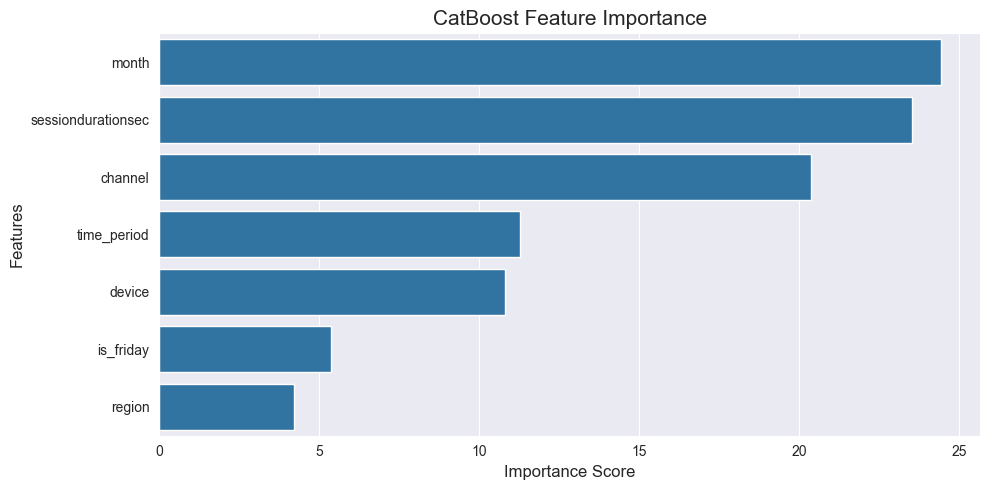

In [179]:
from catboost import Pool
train_pool = Pool(X_train, y_train, cat_features=cat_features)

best_model.fit(train_pool)
feature_importance = best_model.get_feature_importance(train_pool)

feature_names = X_train.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('CatBoost Feature Importance', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

### Итог

**Вывод:** теперь четко видно, что наибольшую важность имеют столбцы sessiondurationsec, month, time_period и channel. is_friday и device по также имеют важность, но меньше. регион почти не важен

# Ответ на вопрос.

Нам был дан вопрос: в какой регион и какой рекламный канал инвестировать больше денег на привлечение клиентов в следующем году и обосновать свои предложения?

В качестве ответа на вопрос мы можем дать рекомендации:
- Концентрировать рекламу пользователям из USA и UK по Пятницам
- Концентрировать рекламу на лето
- Осенью и весной в пользователям PC, Mac и iPhone, живущих в USA, UK и Германии концентрировать рекламу на ‘социальные сети' и 'контекстная реклама’.

In [183]:
data

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,month,day,hour_of_day,...,payer,final_price,time_period,date,is_friday,is_summer,fast_reklama,region_group,flag_country,flag_device
1,601292388085,United States,PC,organic,2019-05-01 06:56:16,2019-05-01 07:09:18,782.000000,5,3,7,...,0,NaN,Утро,2019-05-01,0,False,0,France/Germany,0,1
2,852898876338,United States,Mac,социальные сети,2019-05-01 04:30:45,2019-05-01 04:34:56,251.000000,5,3,4,...,0,NaN,Ночь,2019-05-01,0,False,1,France/Germany,0,1
3,998513020664,United States,iPhone,социальные сети,2019-05-01 18:53:42,2019-05-01 18:57:35,233.000000,5,3,18,...,0,NaN,Вечер,2019-05-01,0,False,1,France/Germany,0,1
4,240702200943,United States,Mac,социальные сети,2019-05-02 14:04:32,2019-05-02 14:09:51,319.000000,5,4,14,...,0,NaN,День,2019-05-02,0,False,1,France/Germany,0,1
5,271758921583,United States,iPhone,социальные сети,2019-05-02 08:40:35,2019-05-02 08:41:15,40.000000,5,4,8,...,0,NaN,Утро,2019-05-02,0,False,1,France/Germany,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,246163171672,United States,iPhone,социальные сети,2019-10-29 18:12:24,2019-10-29 18:13:39,75.000000,10,2,18,...,0,NaN,Вечер,2019-10-29,0,False,1,France/Germany,0,1
1008,660140862425,Germany,Android,реклама у блогеров,2019-10-30 19:14:02,2019-10-30 19:46:19,1937.000000,10,3,19,...,0,NaN,Вечер,2019-10-30,0,False,0,France/Germany,1,0
1009,898253063062,France,iPhone,organic,2019-10-30 03:18:22,2019-10-30 04:43:35,5113.000000,10,3,4,...,0,NaN,Ночь,2019-10-30,0,False,0,France/Germany,0,1
1010,780224321316,United States,iPhone,социальные сети,2019-10-31 22:56:17,2019-10-31 23:42:27,2770.000000,10,4,23,...,0,NaN,Ночь,2019-10-31,0,False,1,France/Germany,0,1
